# Pick the best cherries (or drop the rotten ones)
Filter out really bad performers (e.g. subjects that never learned the task, or subjects that have too few trials)

In [4]:
from glue_sessions import *
from psychometric_curves import *

/Users/alexis/PycharmProjects/my_fun/my_fun.py:82: SyntaxWarning: invalid escape sequence '\i'
  plt.xlabel('$\it{t}$ (s)')
/Users/alexis/PycharmProjects/my_fun/my_fun.py:84: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel('$\it{y}$ (t)')


In [5]:
# Magics
%load_ext autoreload
%autoreload 2

In [6]:
# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

In [7]:
experiments = [
    '2AFC_2',
    '2AFC_3',
    '2AFC_4',    # Ephys pilot group (loads of infections)
    # '2AFC_5',    # Ephys group (no evidences)
    '2AFC_6',    # Pharma group
]

df_behavior = glue_groups(experiments)

In [8]:
def check_good_trials(df):
    """
    Check number of good trials per subject (responded & P > 0)
    :param df: DataFrame with behavior data
    :return: Dictionary with number of good trials per subject
    """
    good_trials_per_subject = {}
    subjects = df.Subject.unique()
    print('Number of responded trials per subject with evidences (P > 0):')
    for s in subjects:
        subdf = df[(df.Subject == int(s)) & (df.P > 0) & (df.Miss == 0)]
        n_trials = len(subdf)
        good_trials_per_subject[s] = n_trials
        print(f'{s}: {n_trials} trials')
    print('\n')
    return good_trials_per_subject

In [9]:
def find_bad_subjects(good_trials_per_subject, threshold=1000):
    """Return subjects with less than threshold good trials
    :param good_trials_per_subject: Dictionary with number of good trials per subject
    :param threshold: Minimum number of good trials"""
    return [s for s, n in good_trials_per_subject.items() if n < threshold]

In [20]:
def cherrypick(df_behavior, experiment):
    """
    Cherrypick the best subjects for a given experiment (actually drop the bad ones)
    :param experiment: Experiment name ('2AFC_2-6')
    :return: Psychometric curve plots for the good subjects
    """

    # Find bad subjects
    df = df_behavior[df_behavior.Experiment == experiment]
    subjects = df.Subject.unique().astype(list)
    subjects = [str(int(s)) for s in subjects]  # Convert to list of strings of integers
    good_trials_per_subject = check_good_trials(df)  # Check good trials per subject
    bad_subjects = find_bad_subjects(good_trials_per_subject)  # Find subjects with less than threshold good trials
    print(f'Bad subjects: {bad_subjects}')
    bad_subjects = [float(s) for s in bad_subjects]  # Transform bad subjects back to floats

    # Remove bad subjects from df
    df = df[~df.Subject.isin(bad_subjects)]
    good_subjects = df.Subject.unique().astype(list)
    good_subjects = [str(int(s)) for s in good_subjects]  # Convert to list of strings of integers
    good_subjects = [s.zfill(3) for s in good_subjects]  # Pad with zeros to have 3 digits (needed for group #6)
    print(f'Good subjects: {good_subjects}')

    # Plot psychometric curves
    psych_curve = plot_pc(experiment=experiment, animal=good_subjects, kind='prob_right', drug=None, save=False, format='png', transparent=False)

    return psych_curve

# 2AFC_2

Number of responded trials per subject with P > 0:
325: 7279 trials
326: 2211 trials
327: 9386 trials
328: 0 trials
329: 11541 trials
330: 4658 trials
331: 0 trials
332: 27879 trials
333: 25533 trials
334: 102 trials
335: 12712 trials
337: 20602 trials


Bad subjects: [np.int64(328), np.int64(331), np.int64(334)]
Good subjects: ['325', '326', '327', '329', '330', '332', '333', '335', '337']


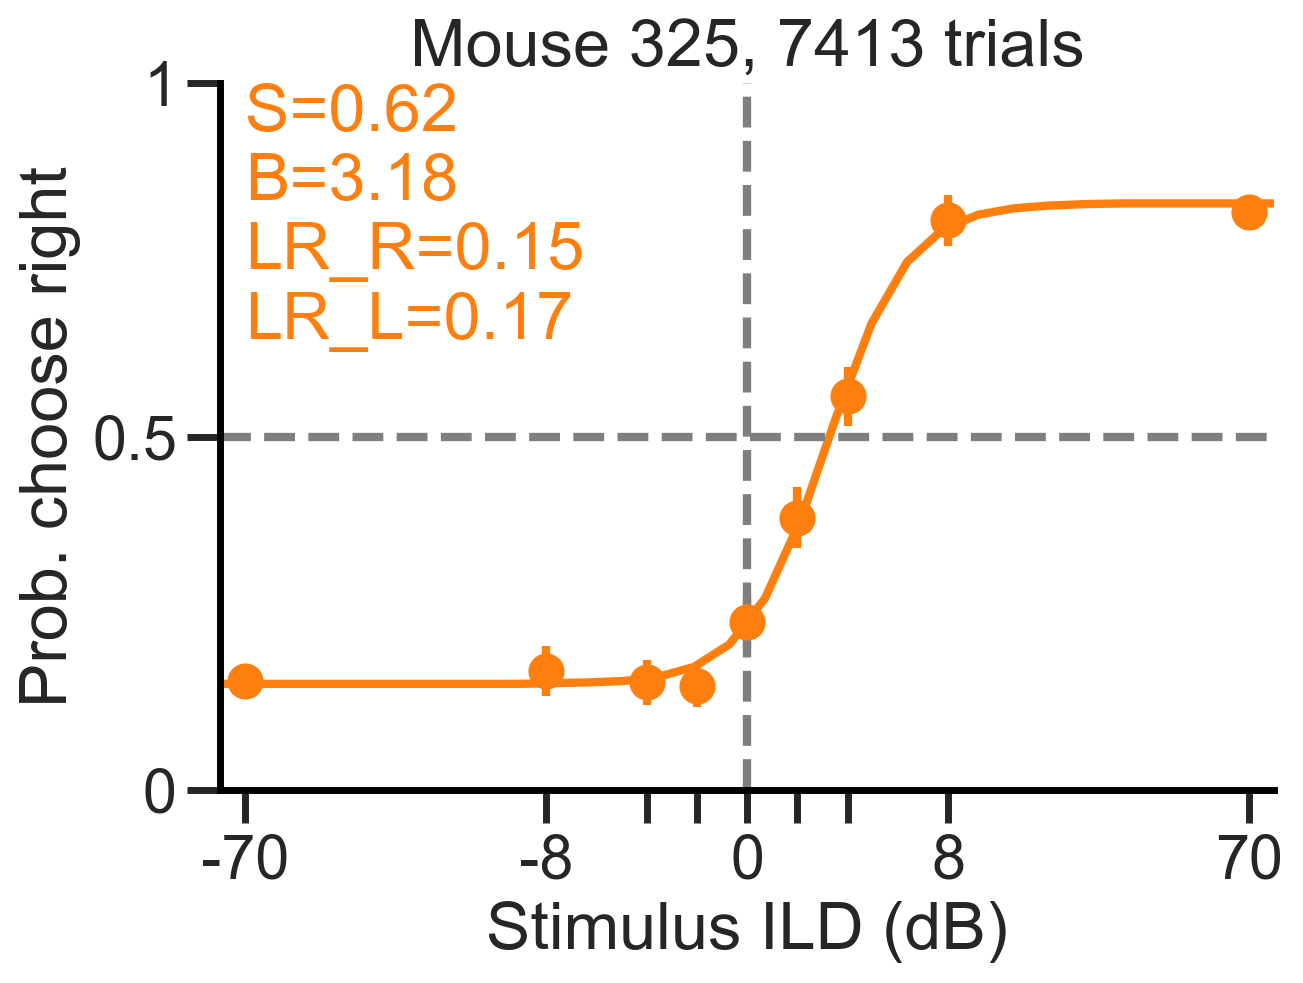

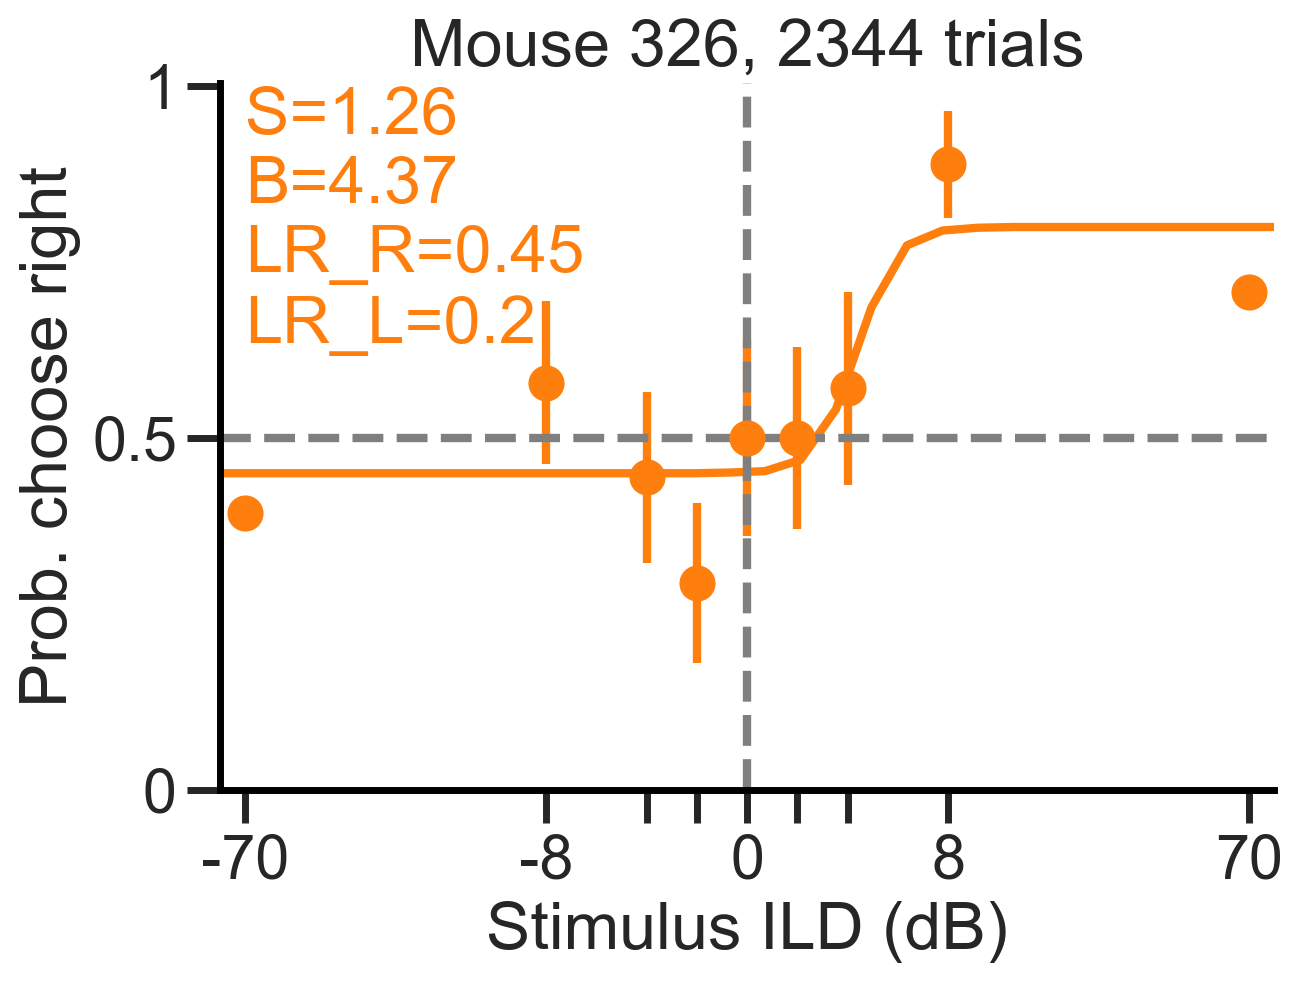

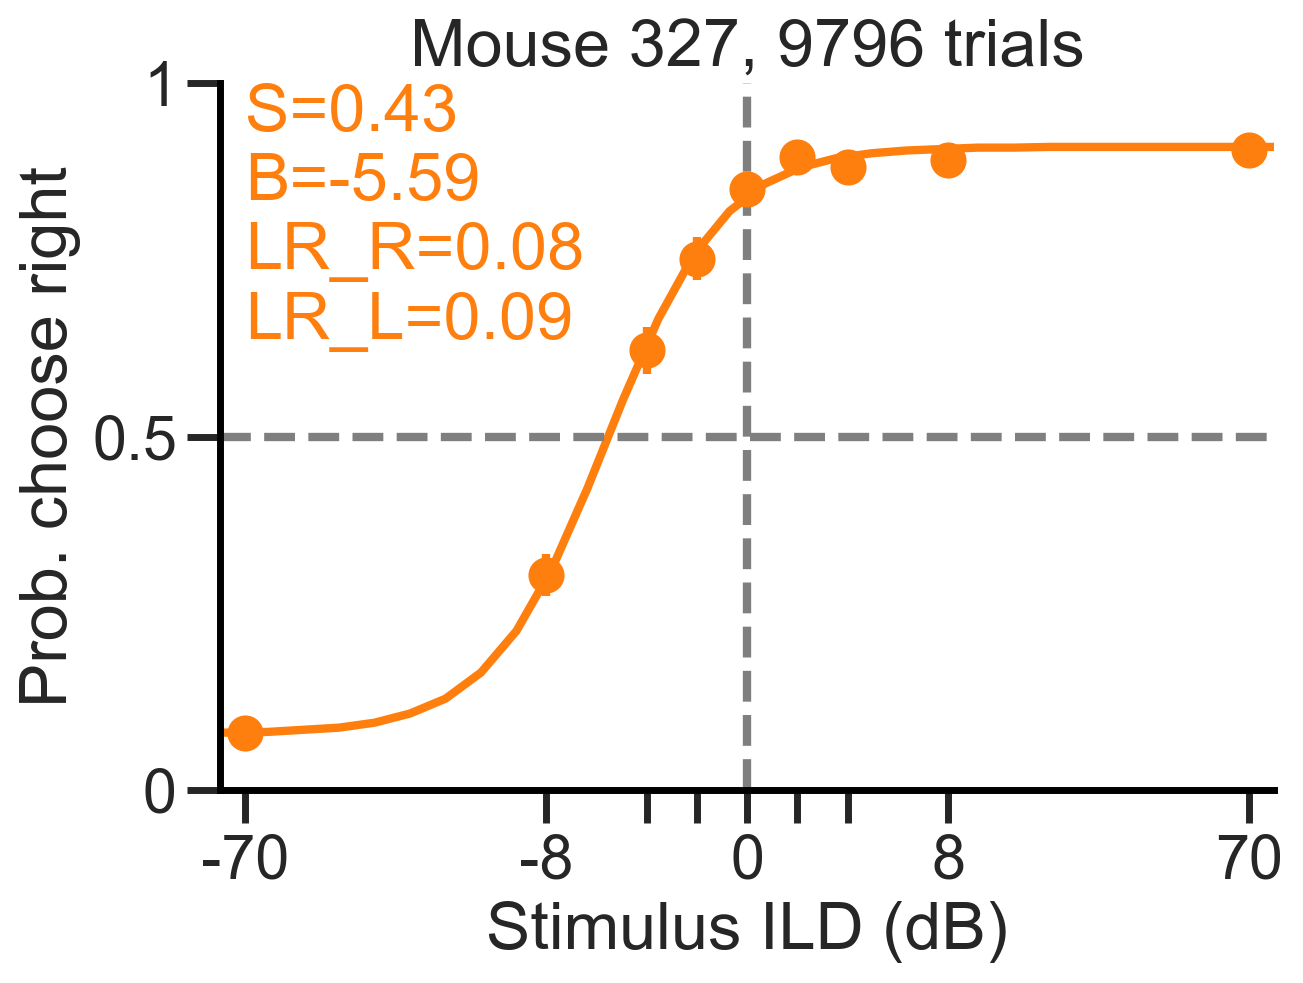

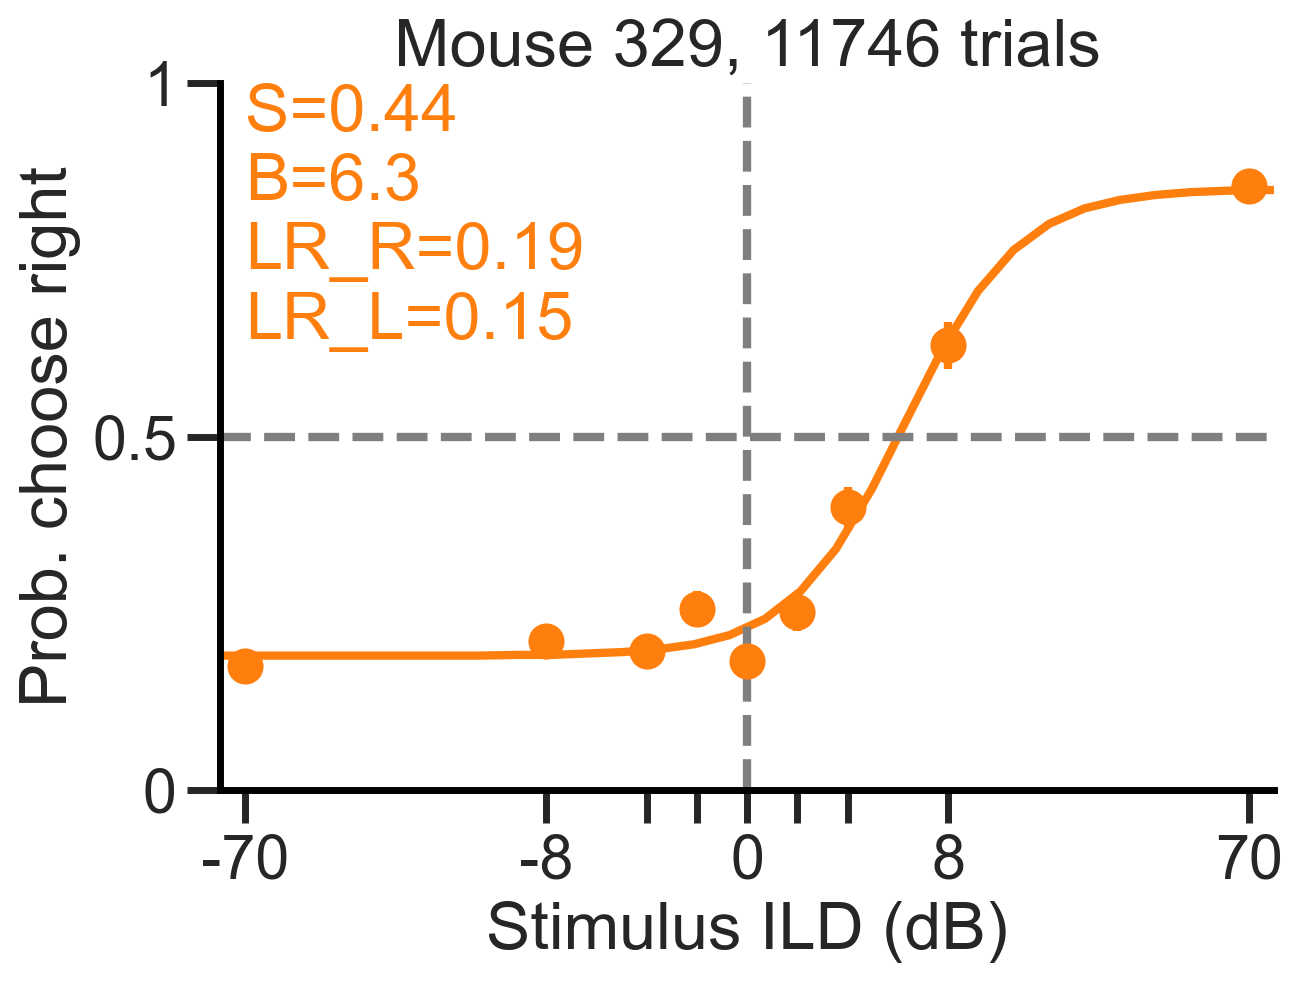

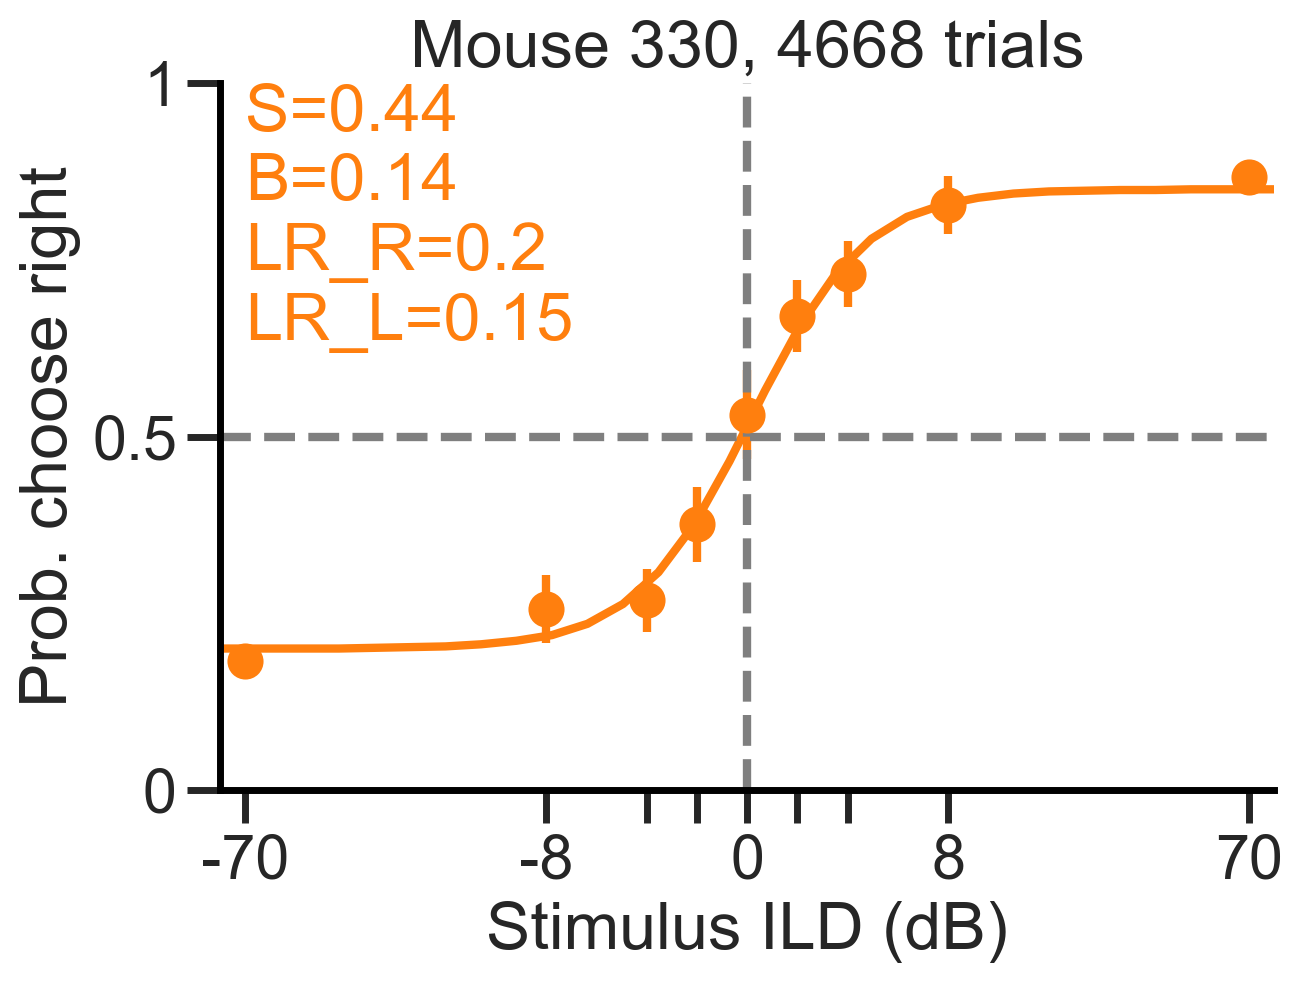

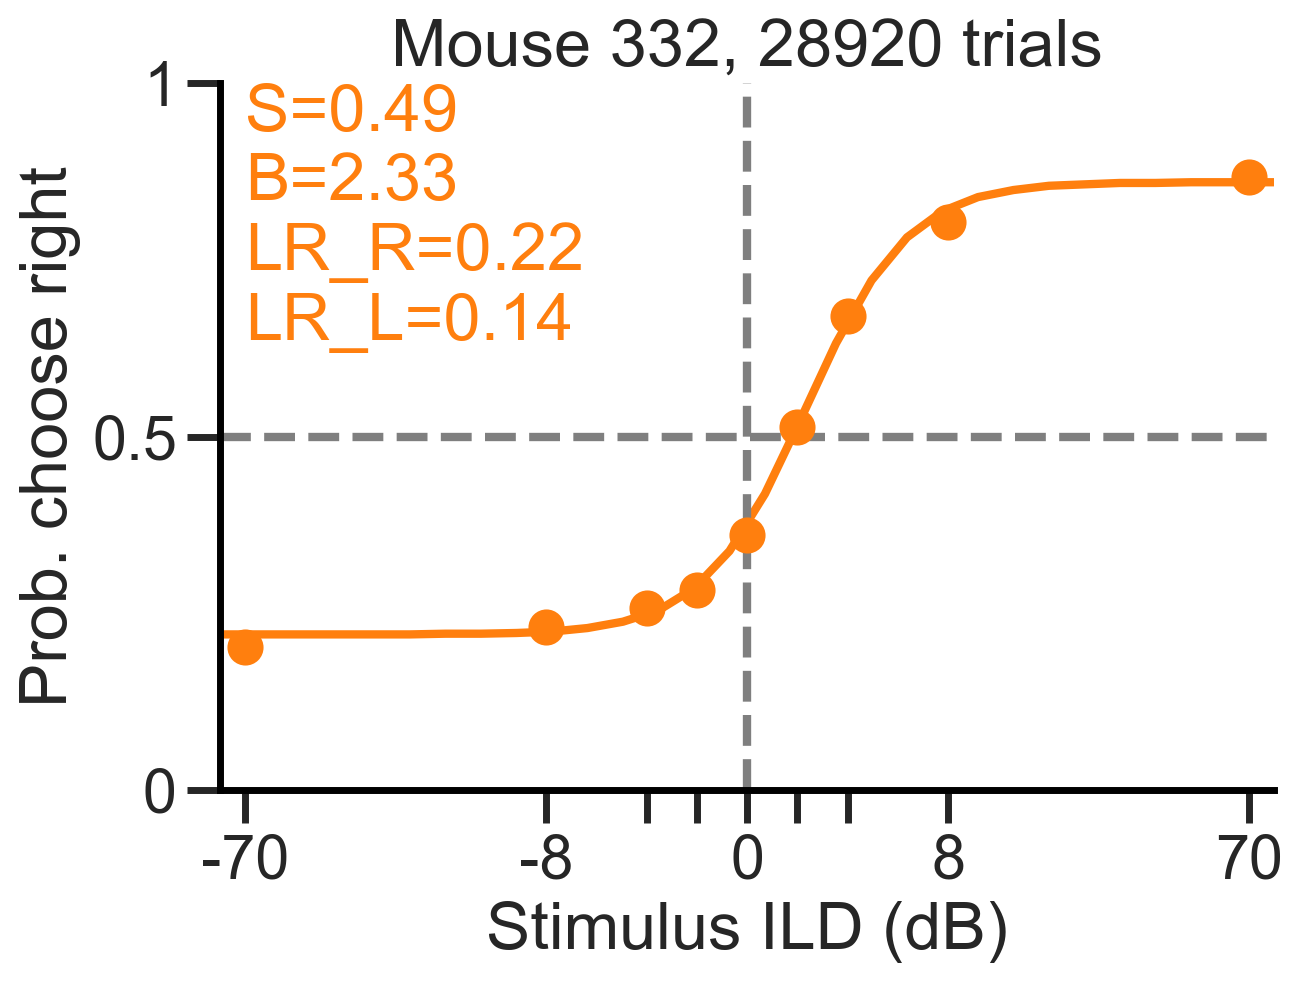

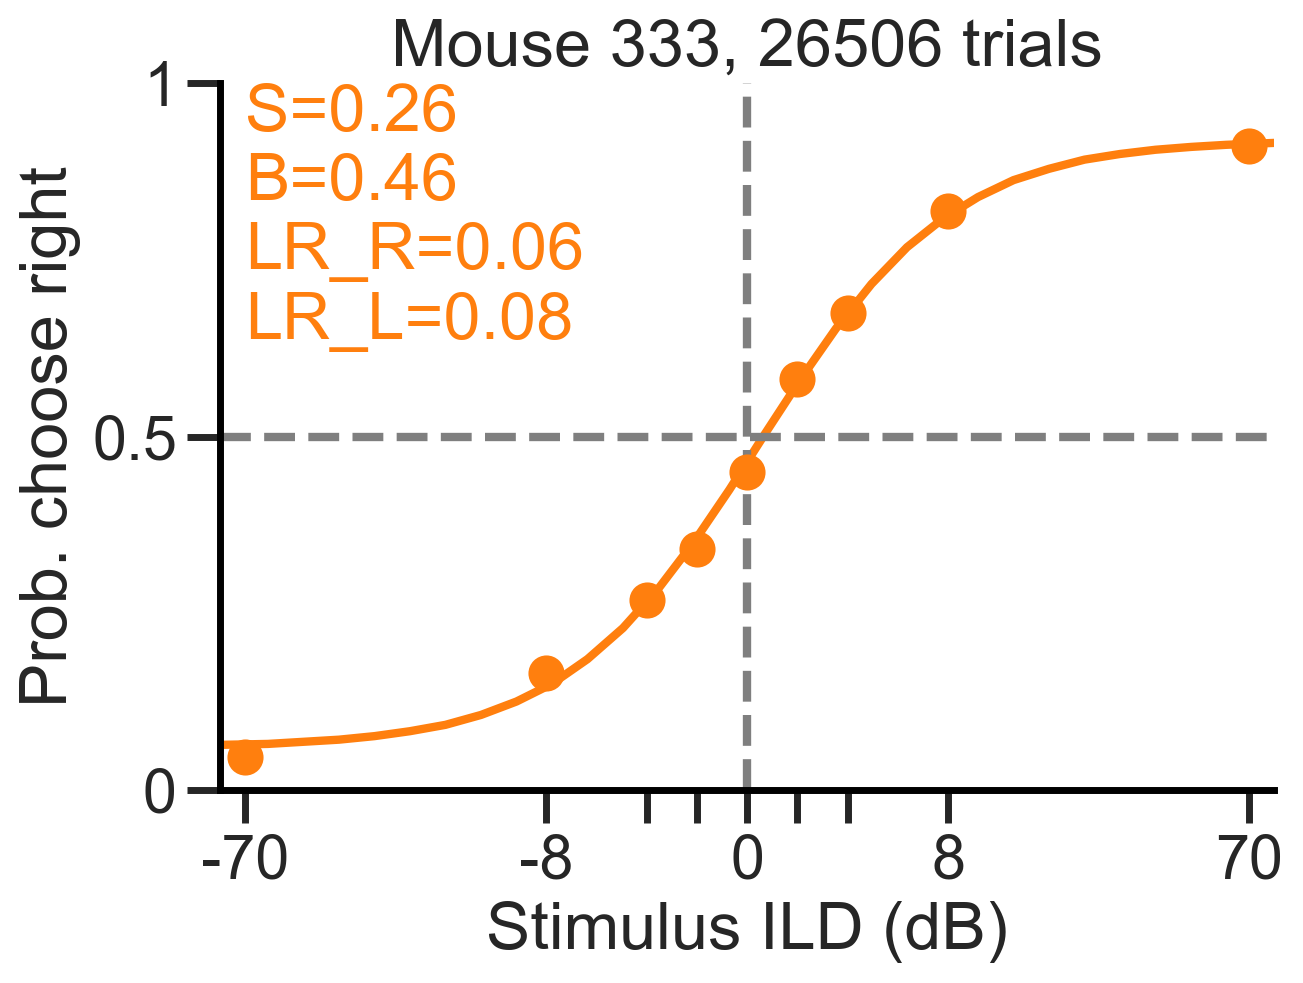

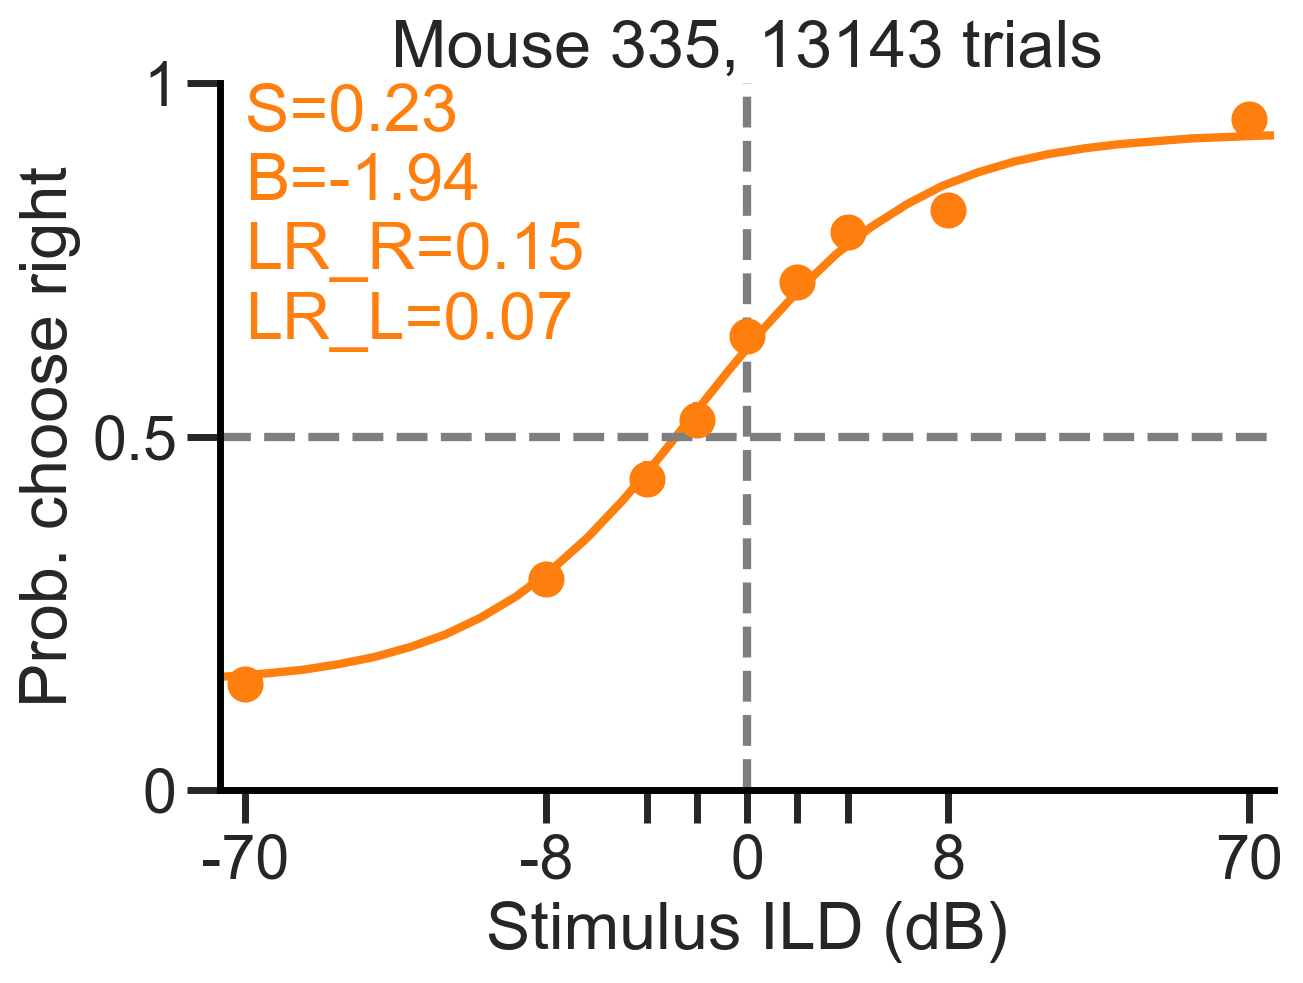

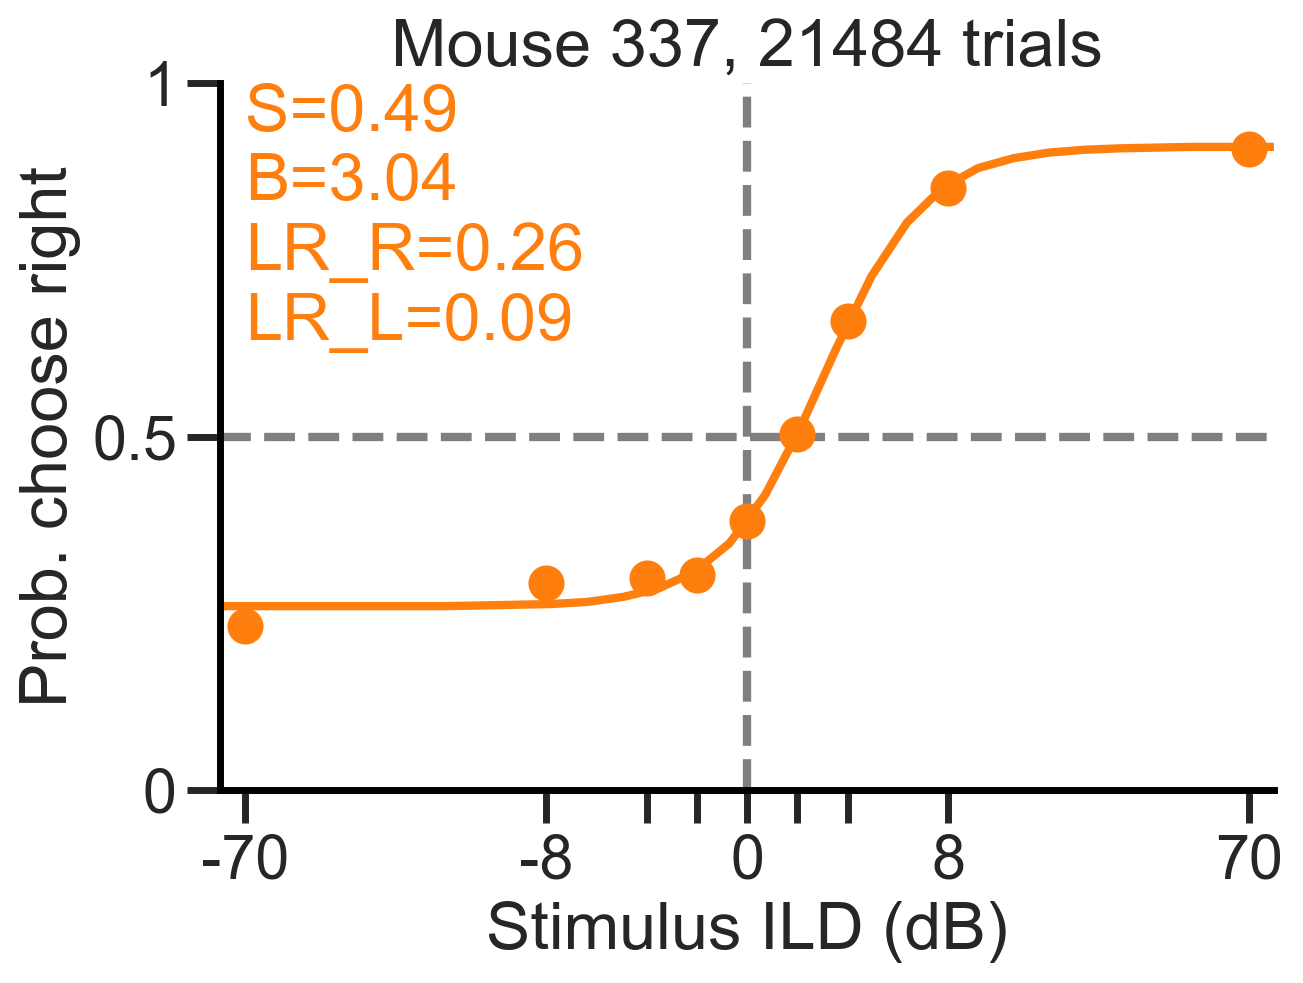

In [21]:
experiment = '2AFC_2'
psych_curve = cherrypick(df_behavior, experiment)

# 2AFC_3

Number of responded trials per subject with P > 0:
387: 0 trials
395: 0 trials
398: 0 trials
419: 10403 trials
420: 20117 trials
422: 21061 trials
501: 0 trials
614: 0 trials
615: 0 trials
616: 14090 trials
617: 1728 trials
618: 0 trials
619: 7257 trials
620: 949 trials
623: 13642 trials
625: 0 trials
627: 0 trials


Bad subjects: [np.int64(387), np.int64(395), np.int64(398), np.int64(501), np.int64(614), np.int64(615), np.int64(618), np.int64(620), np.int64(625), np.int64(627)]
Good subjects: ['419', '420', '422', '616', '617', '619', '623']


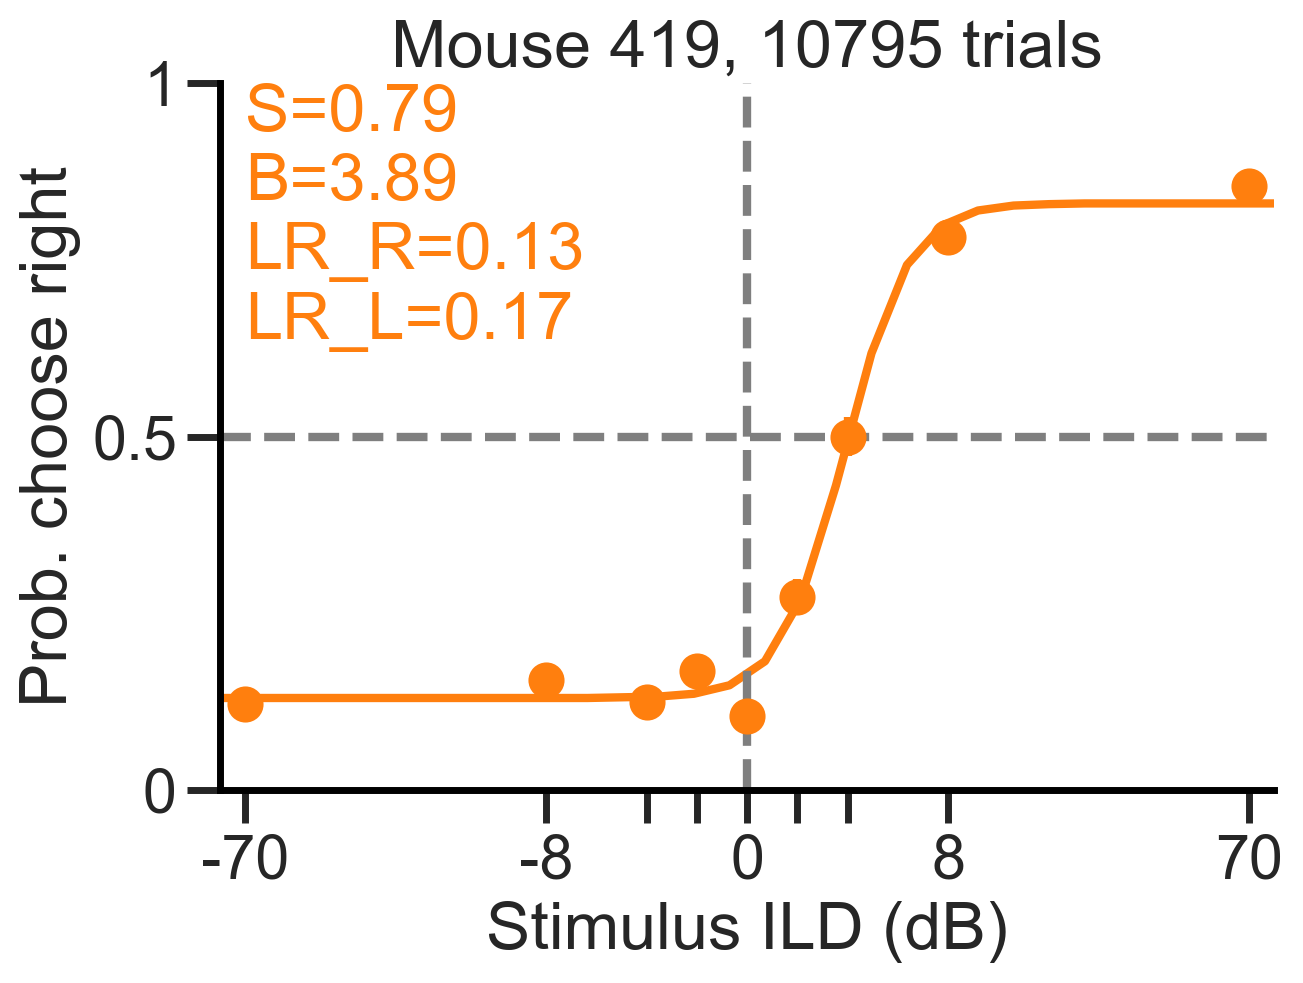

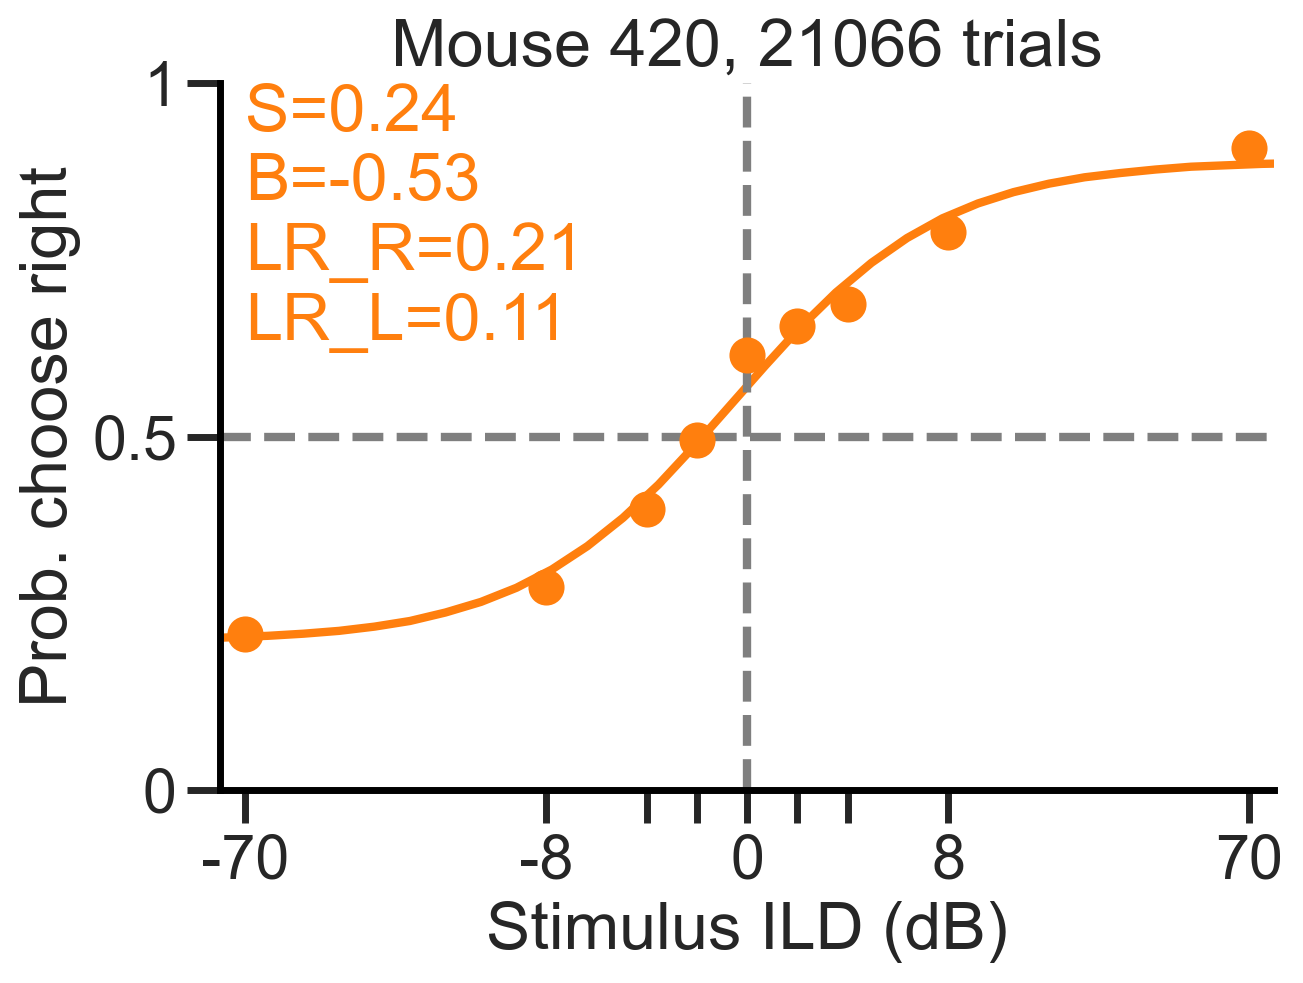

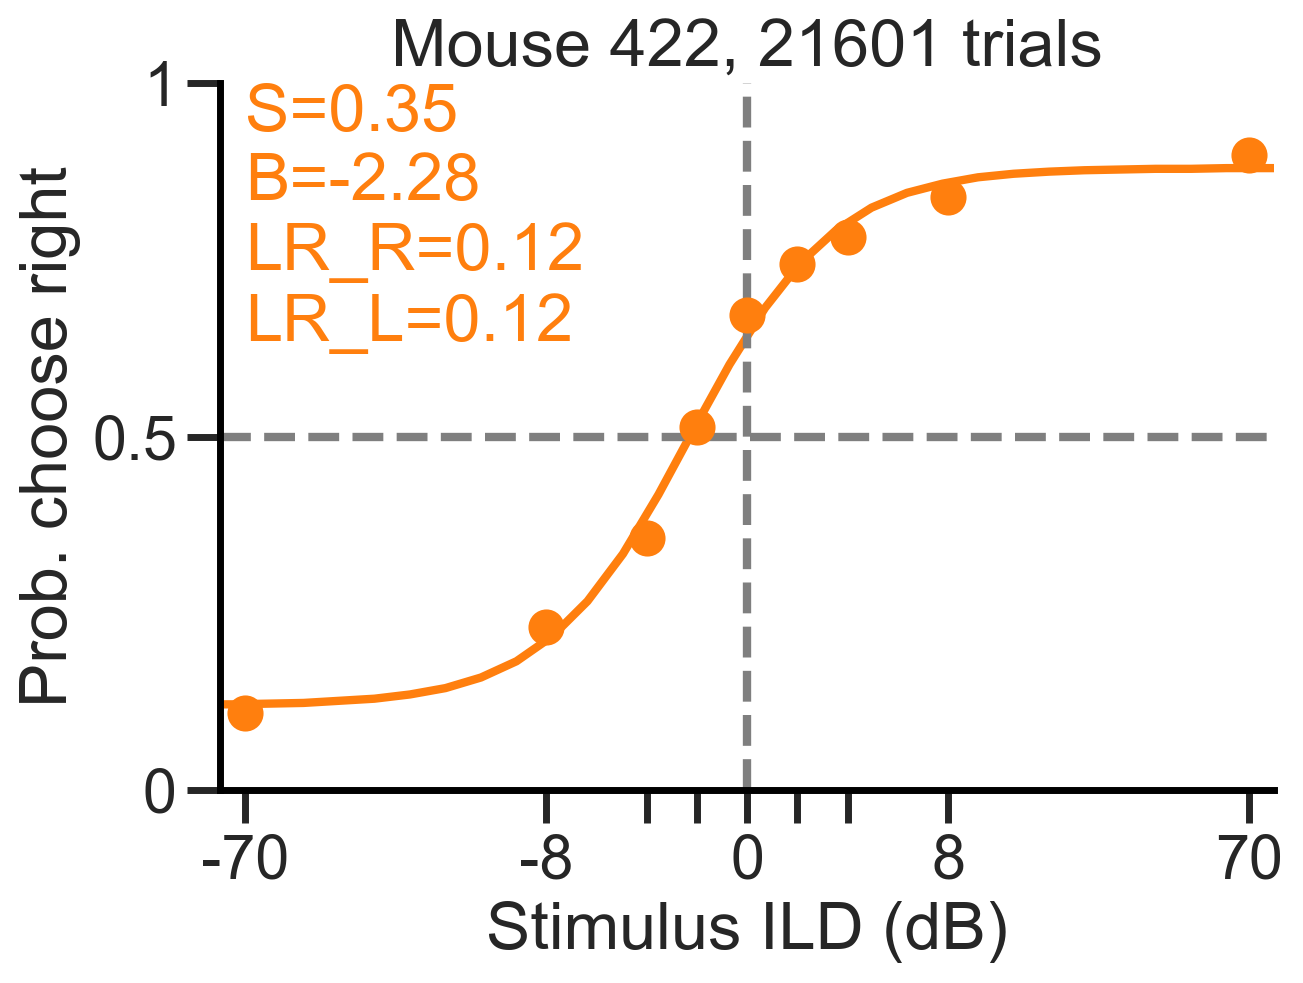

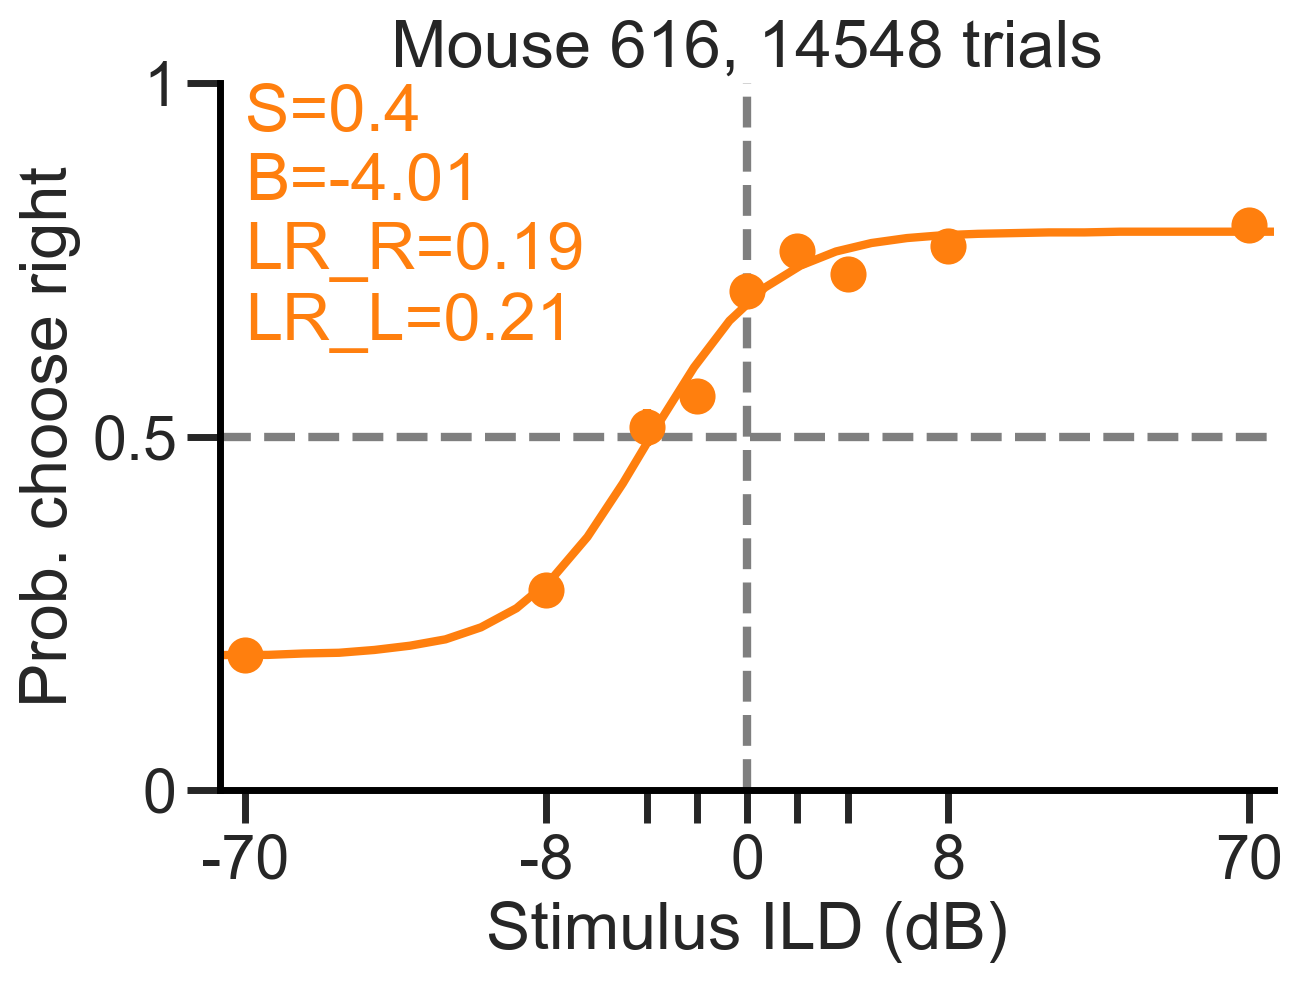

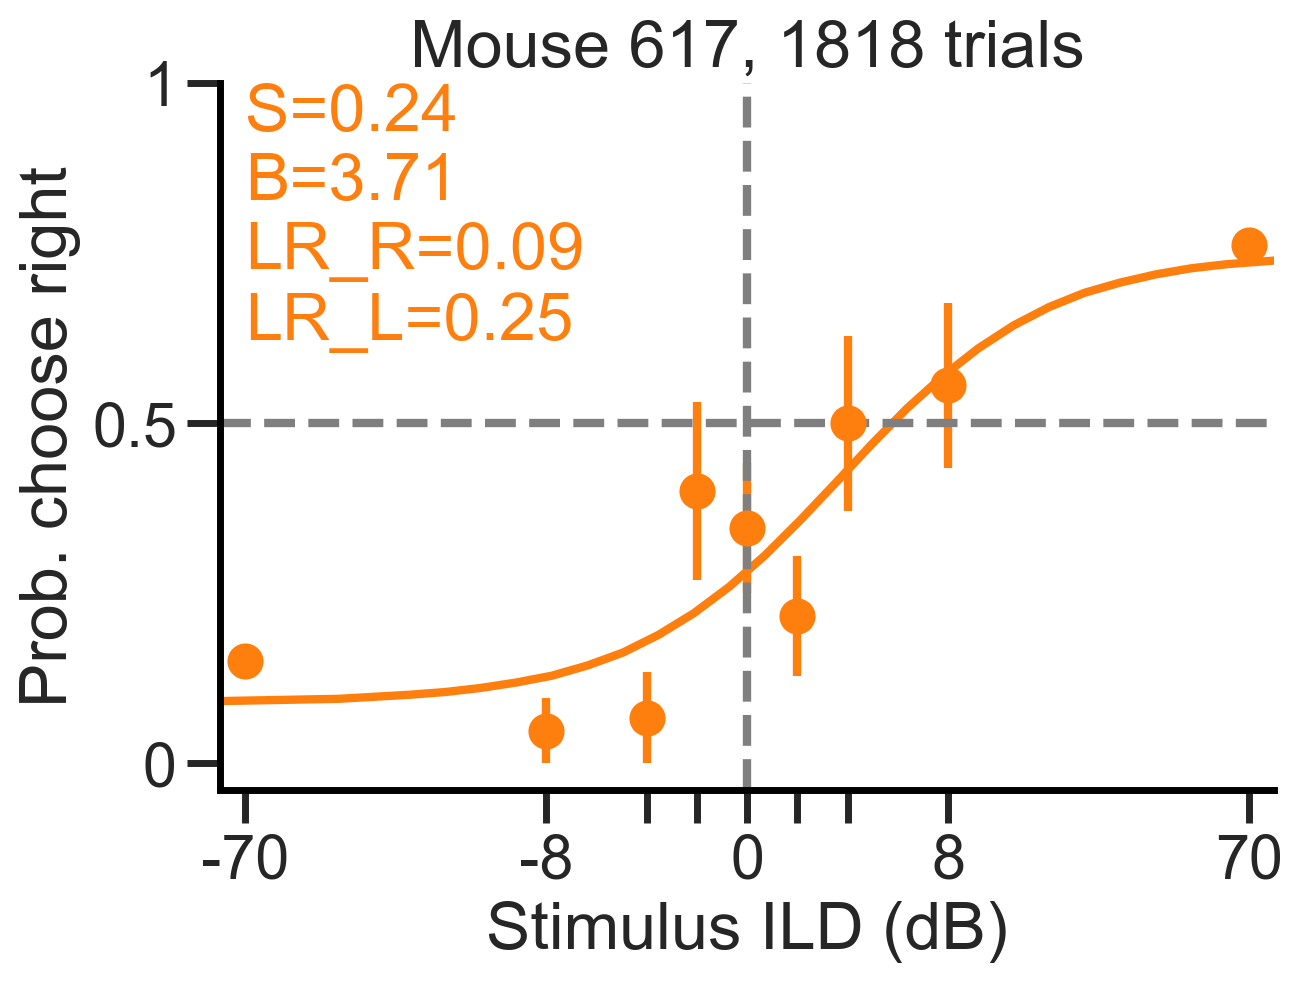

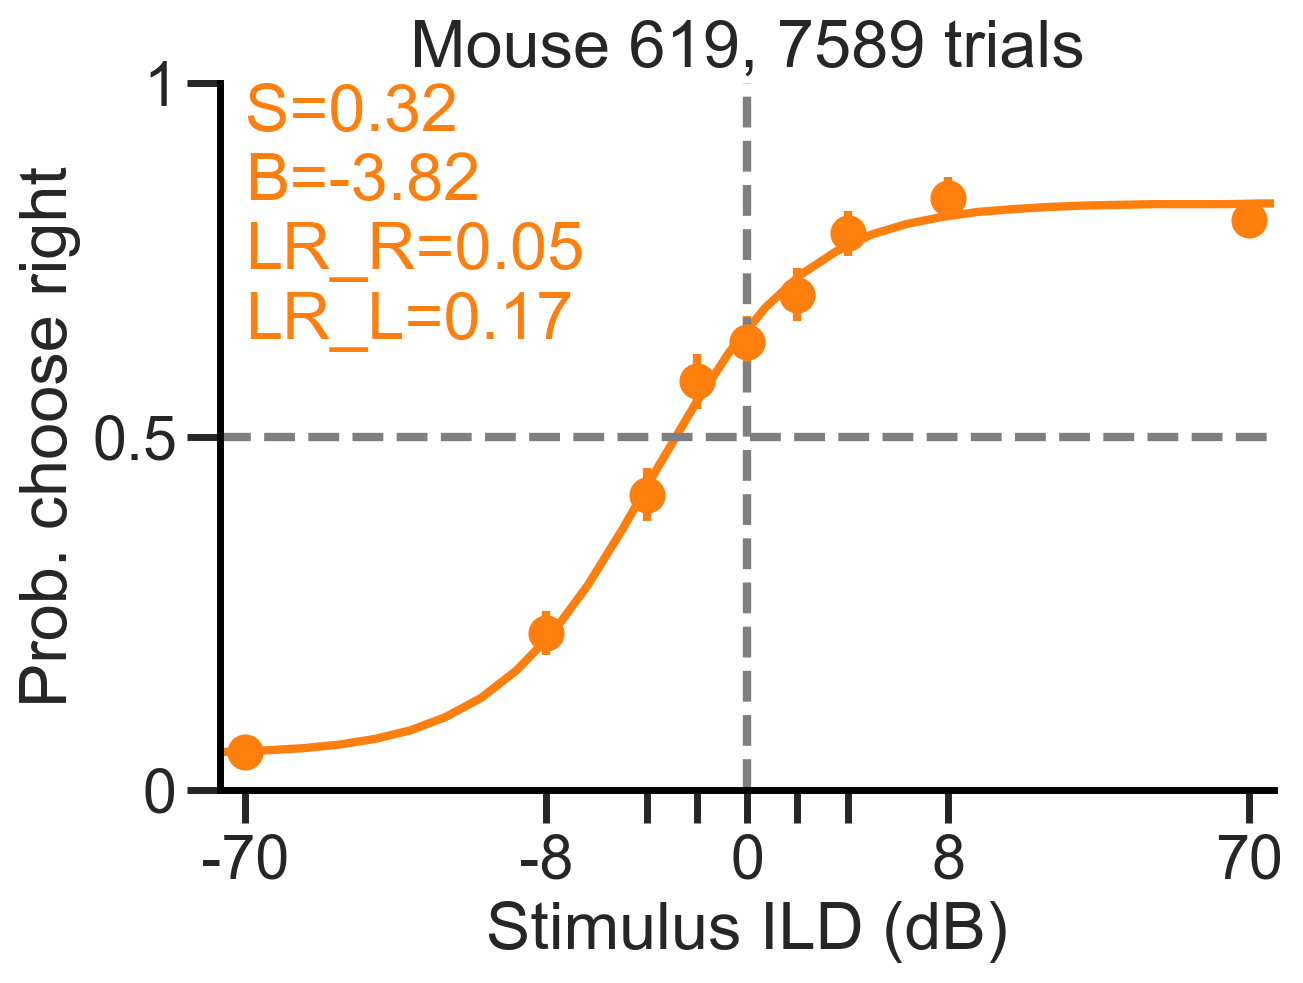

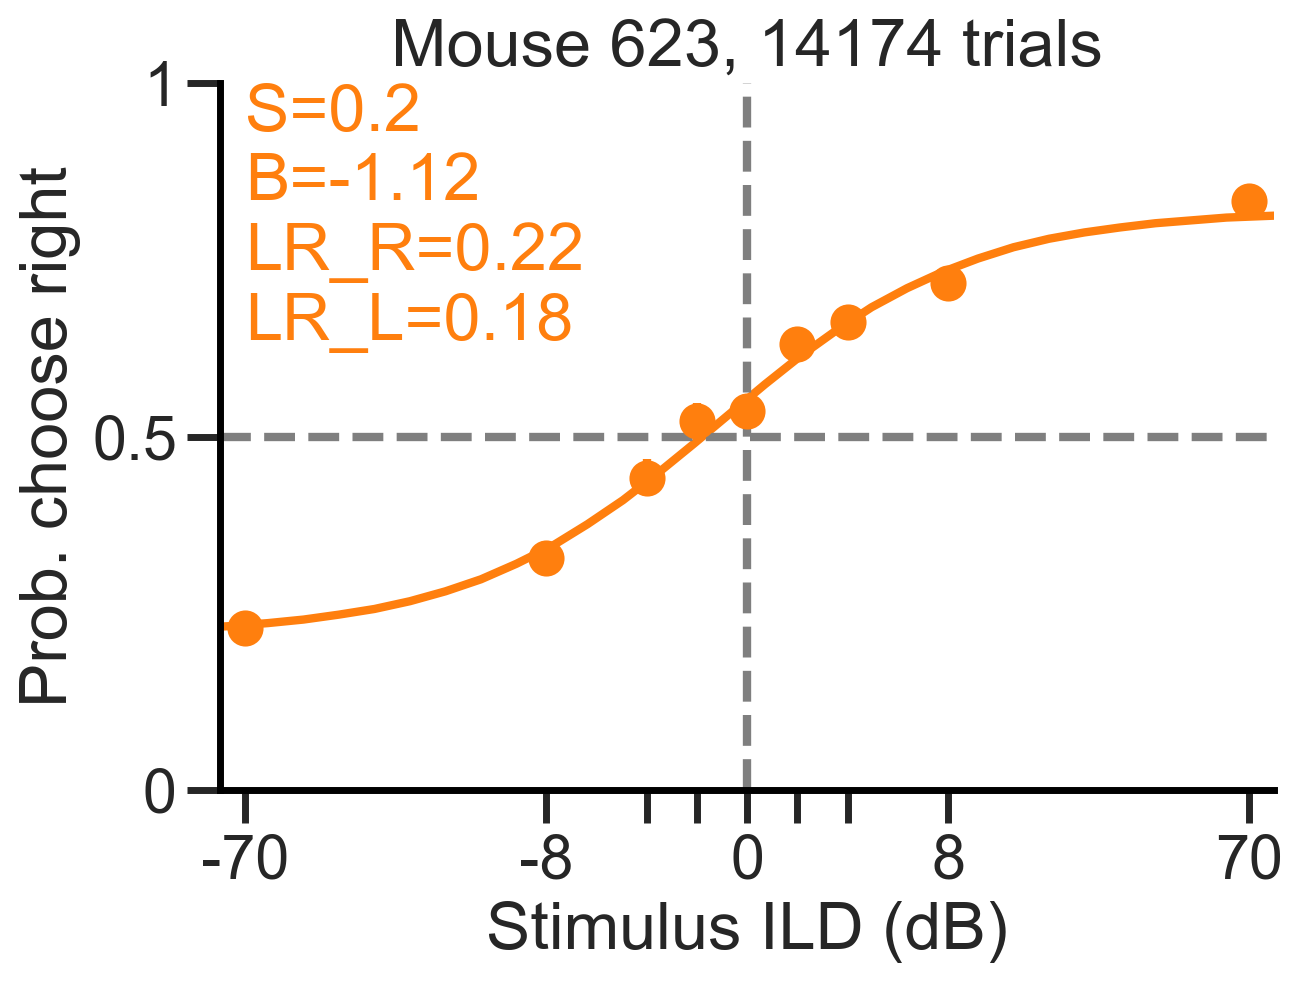

In [12]:
experiment = '2AFC_3'
cherrypick(df_behavior, experiment)

# 2AFC_4
Ephys pilot group (loads of infections)

Number of responded trials per subject with P > 0:
561: 8079 trials
562: 0 trials
791: 0 trials
801: 0 trials
802: 0 trials
804: 0 trials
807: 4259 trials
808: 0 trials
820: 31998 trials
821: 37049 trials
873: 25979 trials
875: 16135 trials
876: 2504 trials
907: 36258 trials
909: 13755 trials
911: 35334 trials


Bad subjects: [np.int64(562), np.int64(791), np.int64(801), np.int64(802), np.int64(804), np.int64(808)]
Good subjects: ['561', '807', '820', '821', '873', '875', '876', '907', '909', '911']


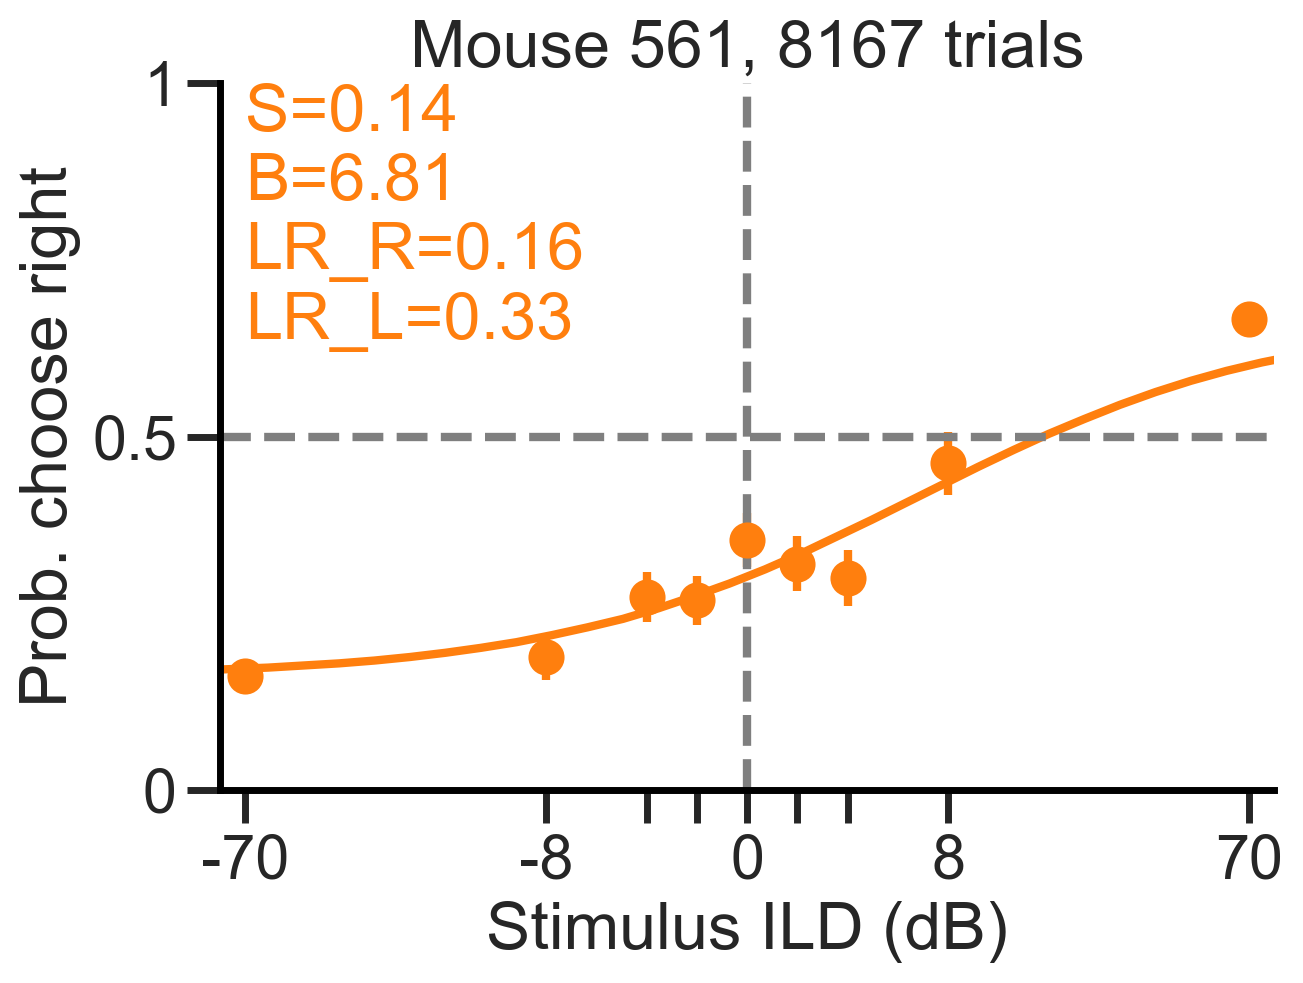

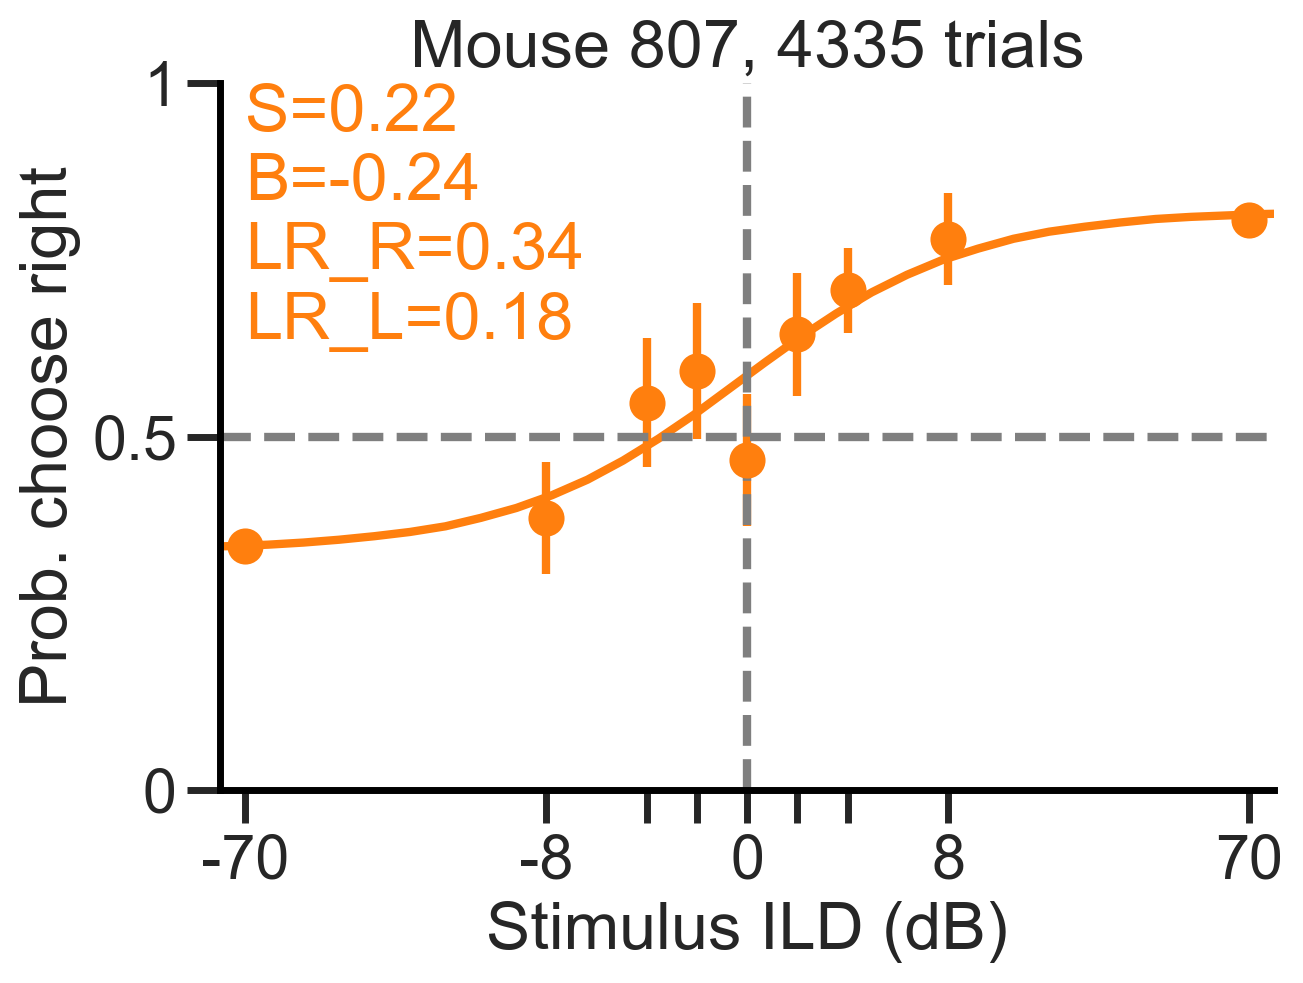

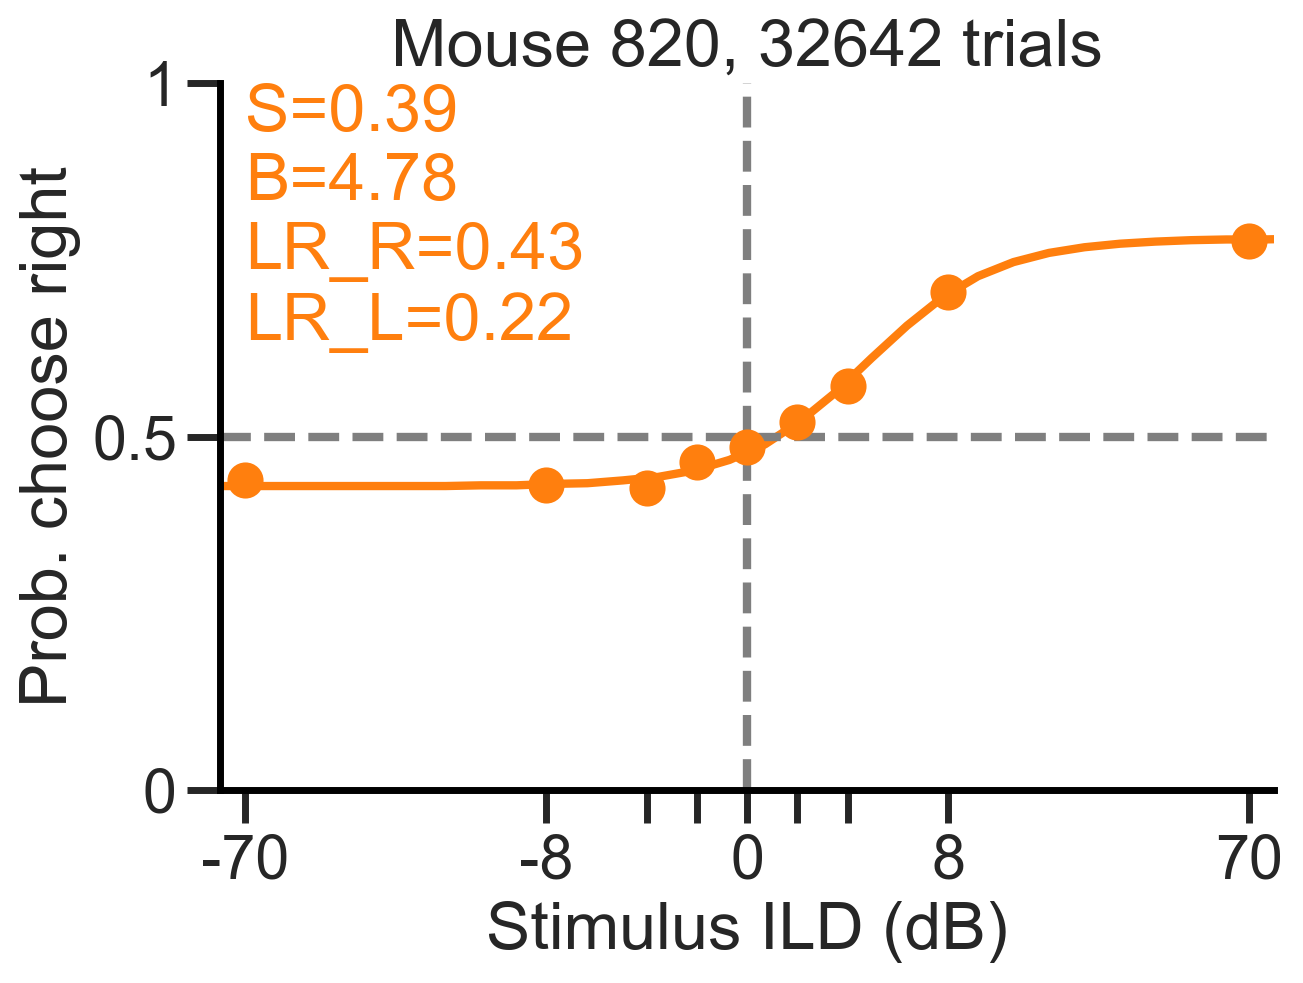

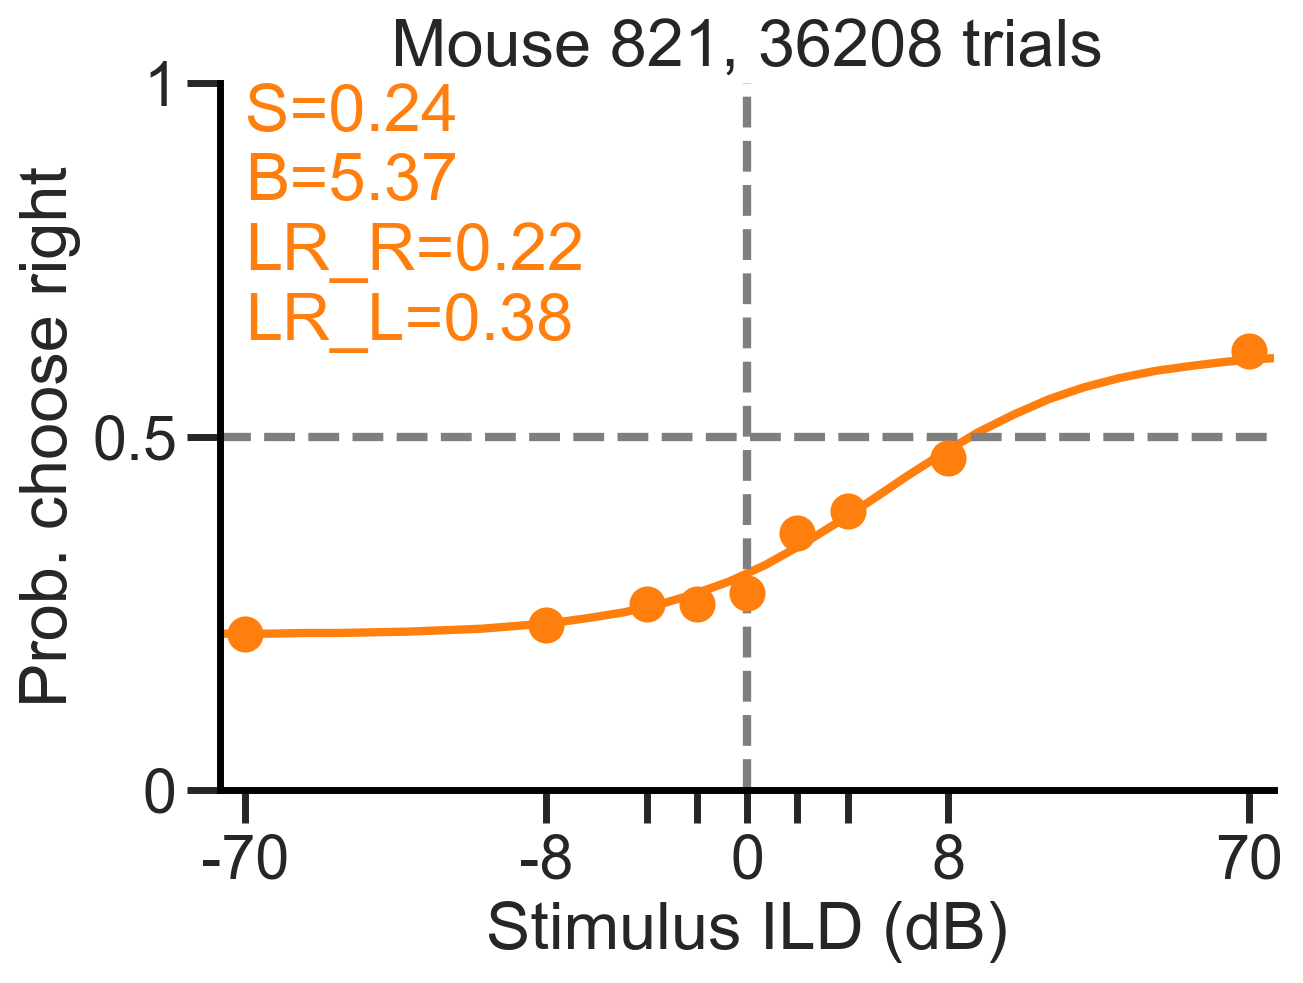

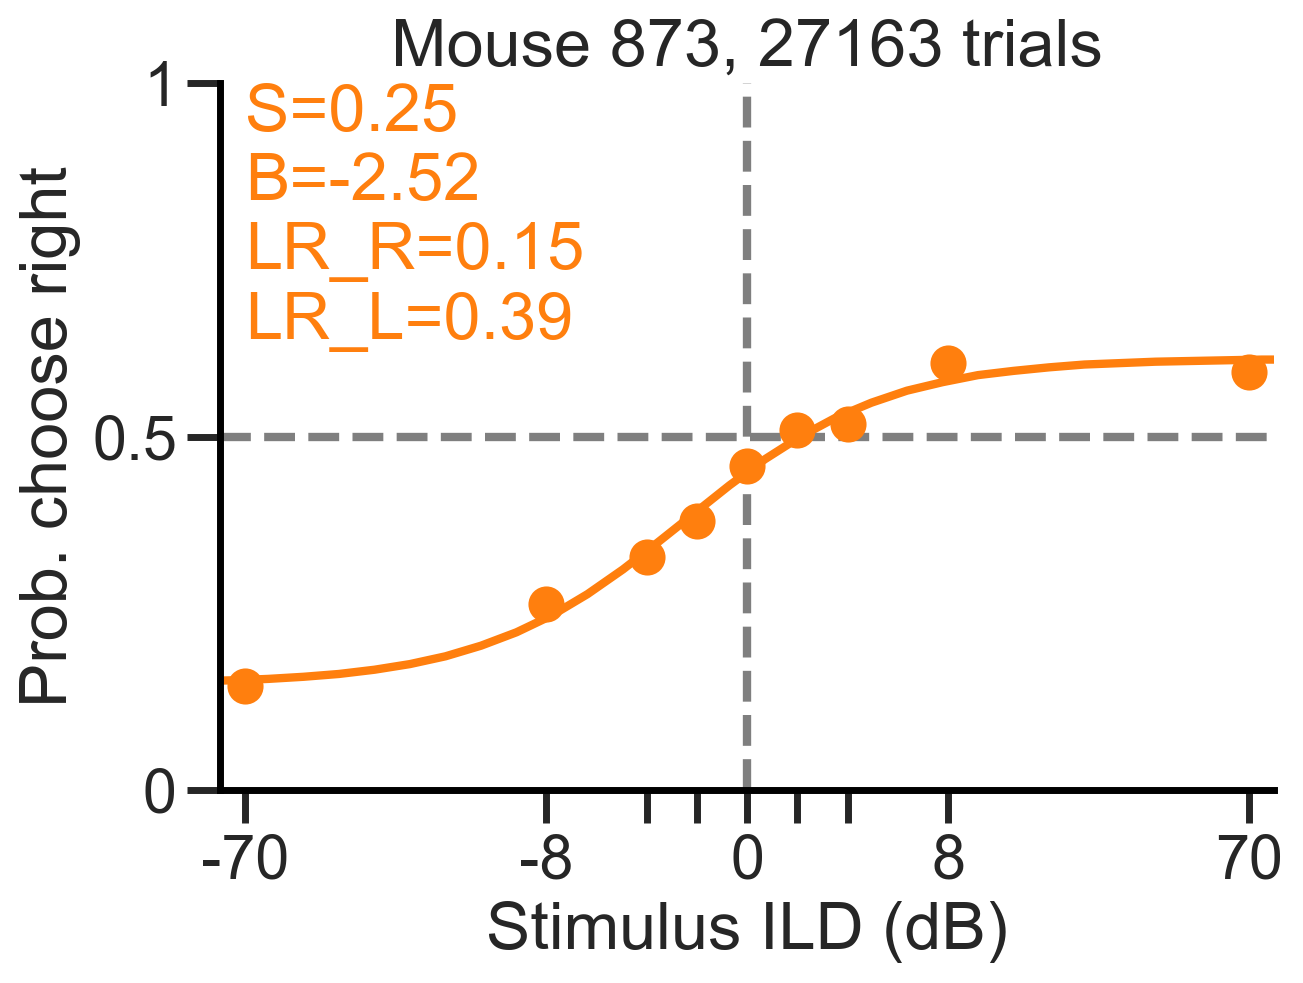

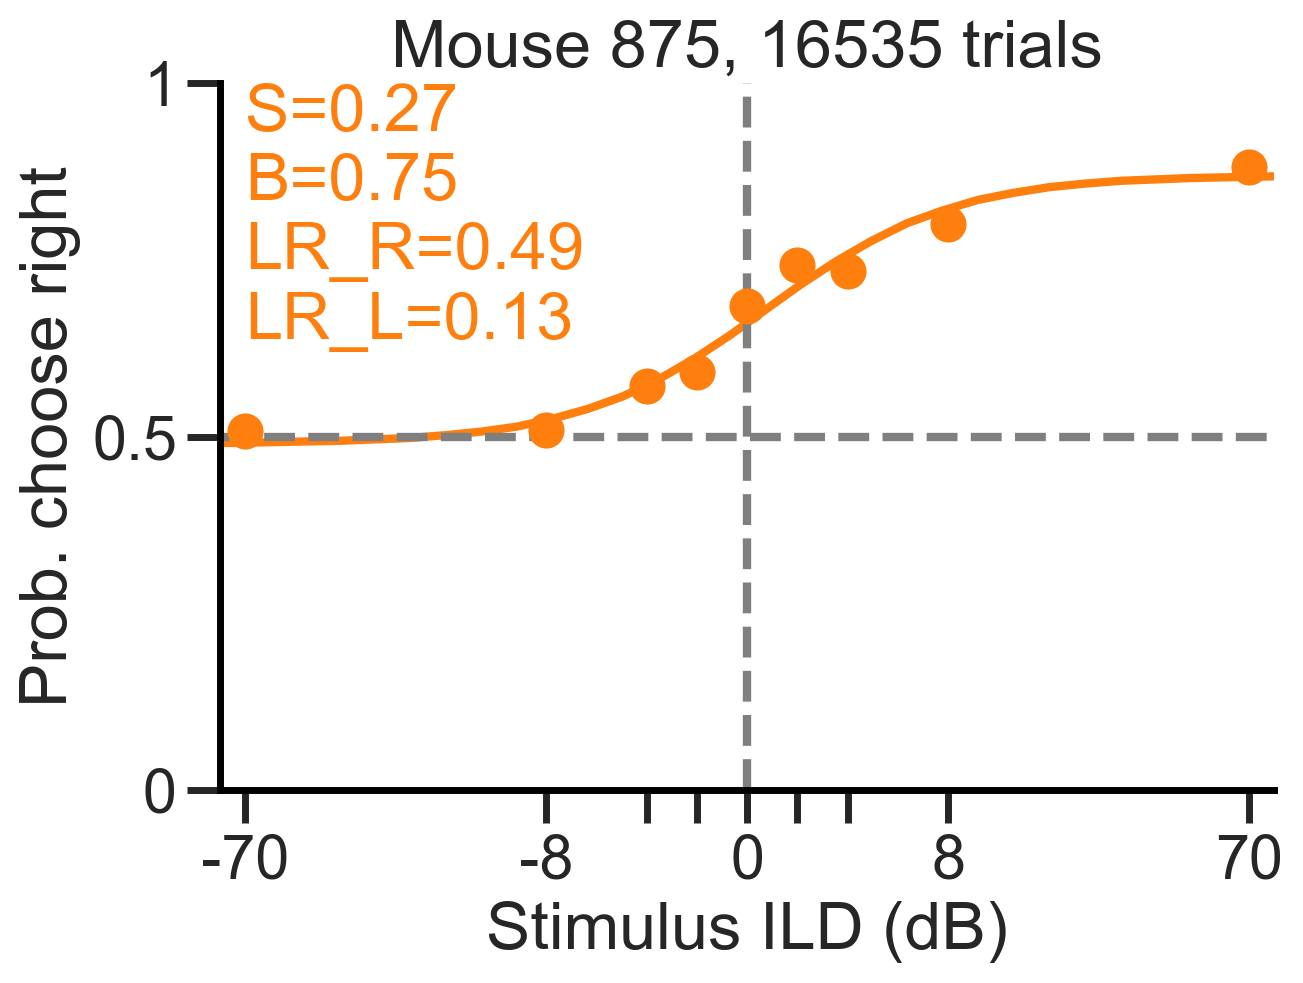

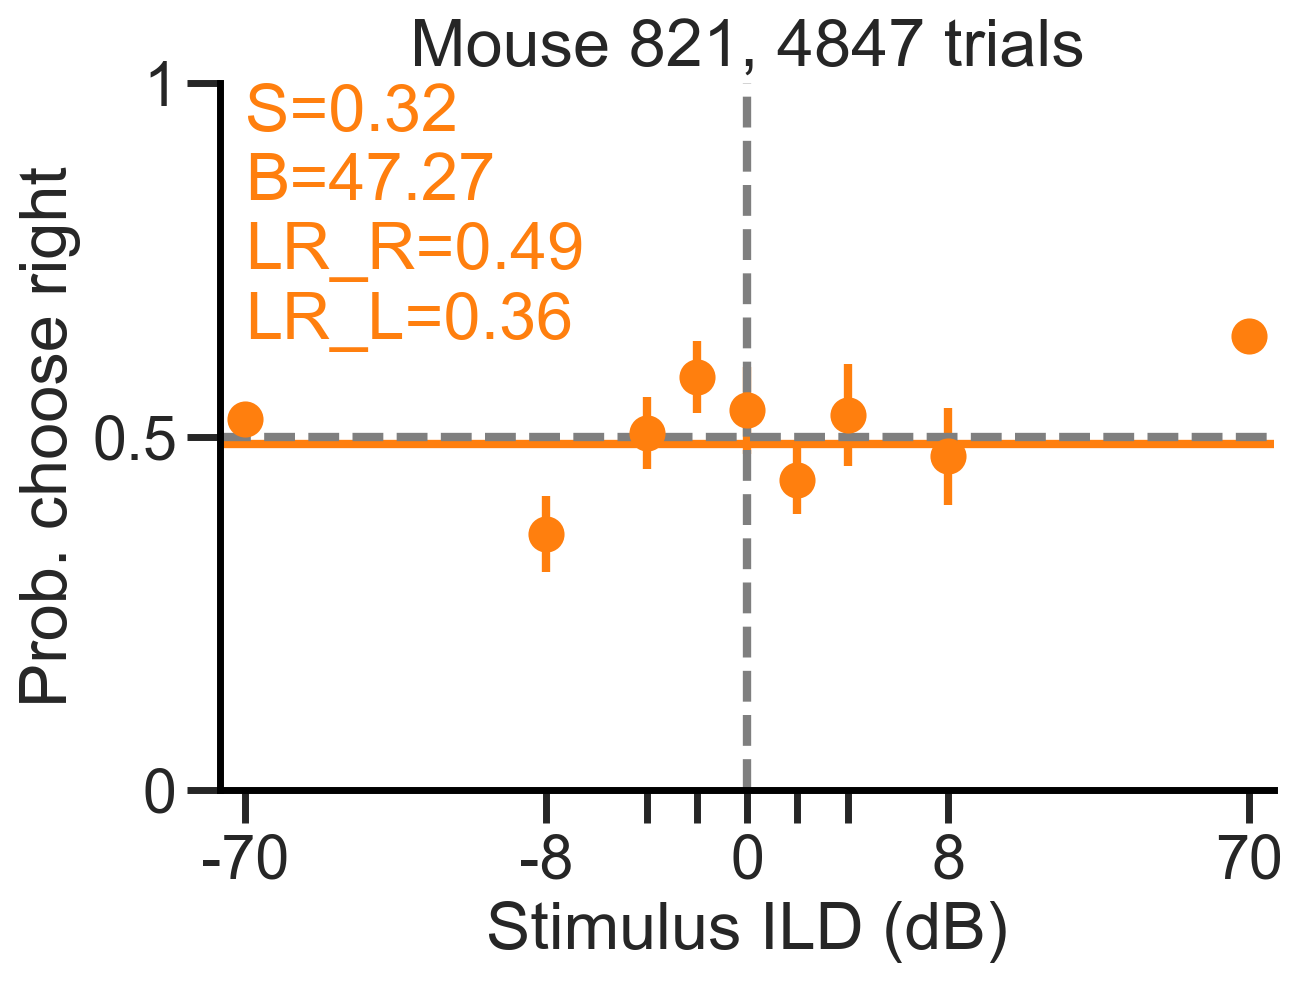

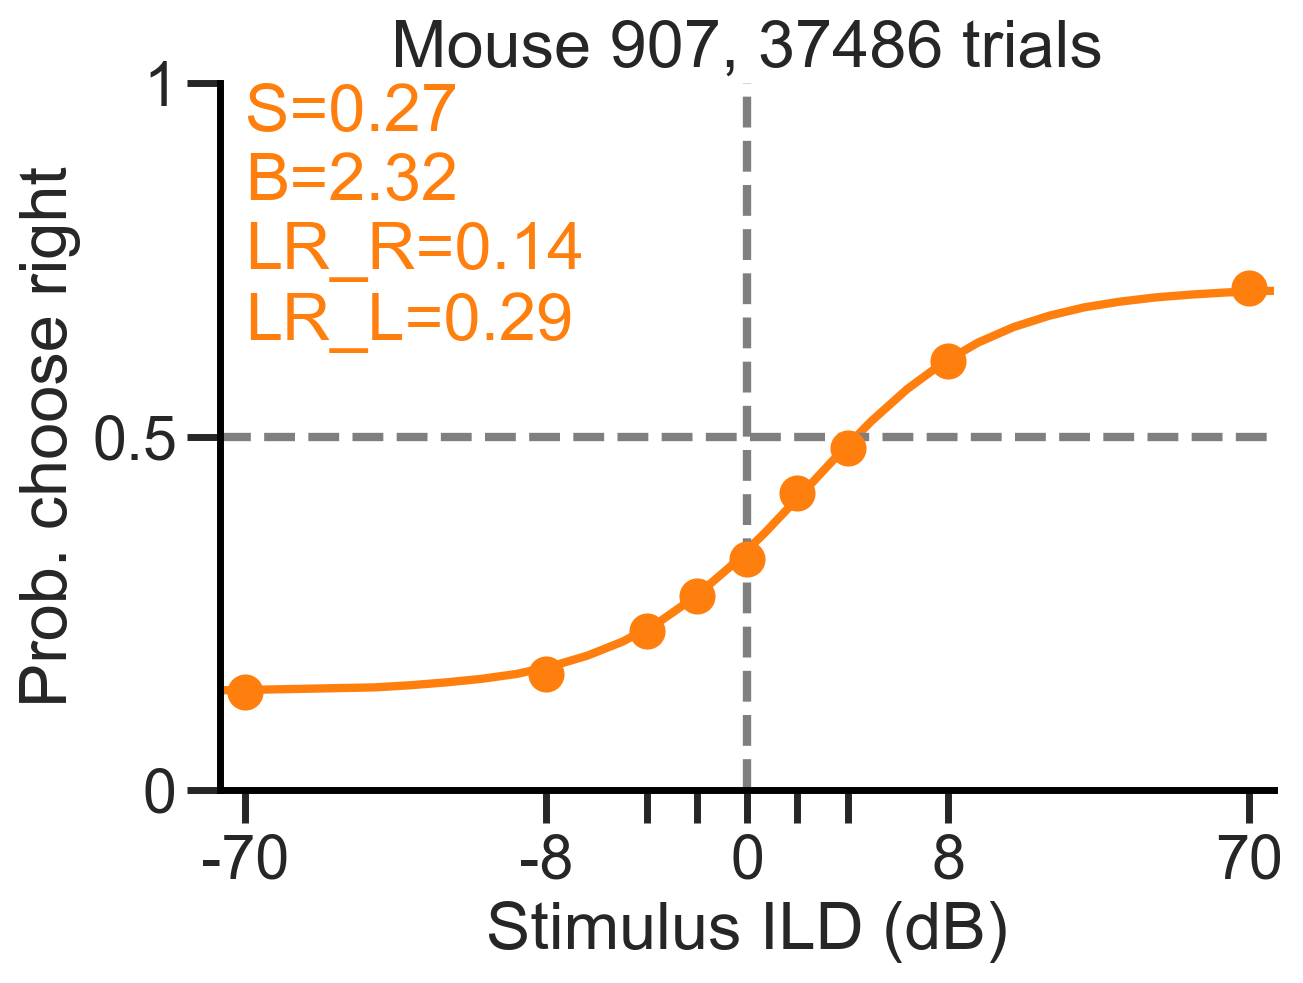

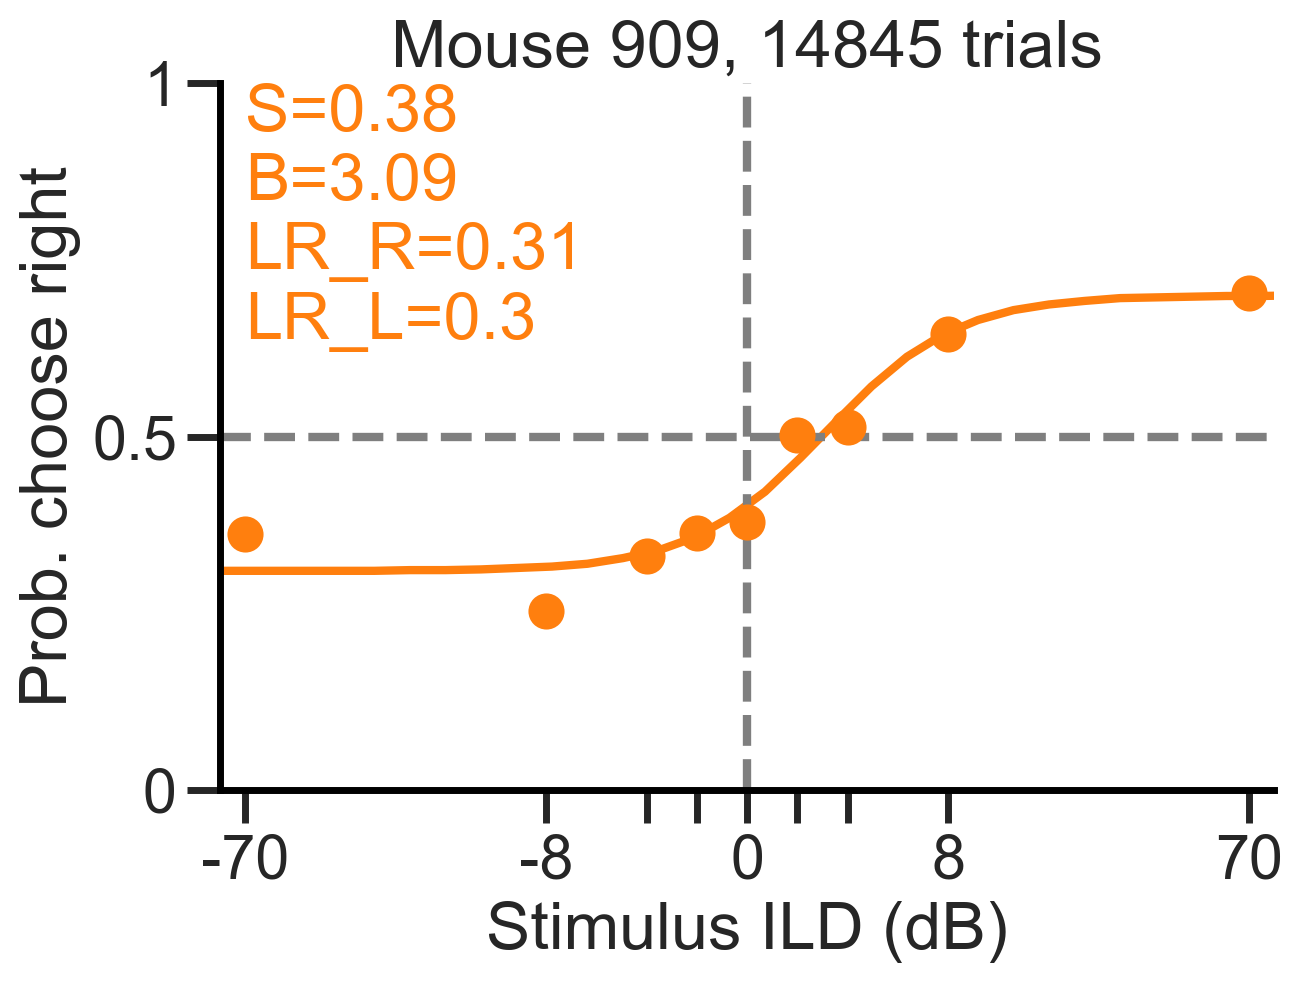

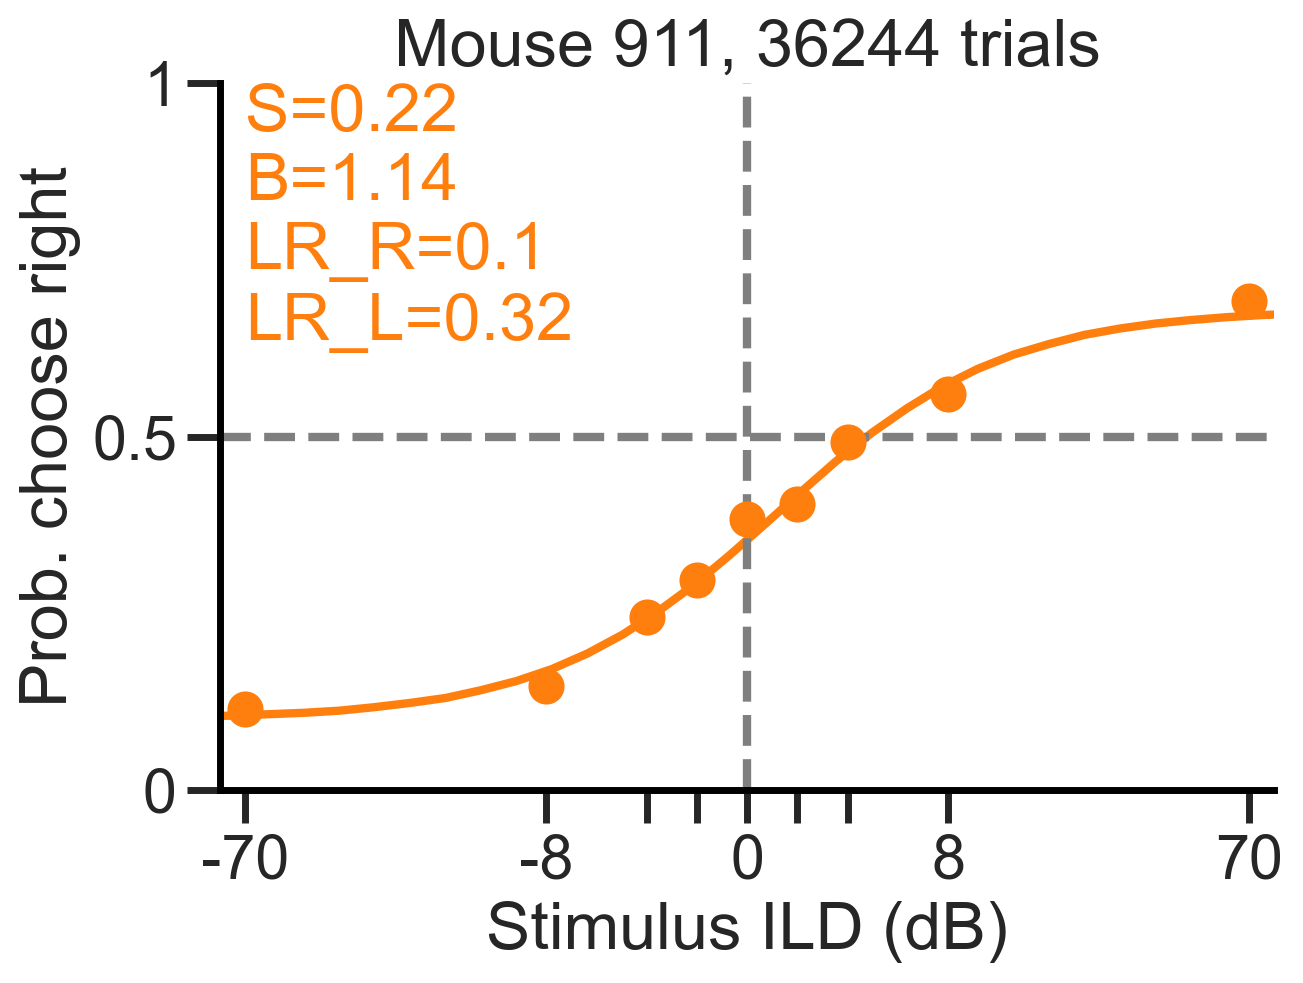

In [13]:
experiment = '2AFC_4'
cherrypick(df_behavior, experiment)

# 2AFC_5
Ephys group (no evidences)

In [14]:
experiment = '2AFC_5'
cherrypick(df_behavior, experiment)

Number of responded trials per subject with P > 0:


Bad subjects: []
Good subjects: []


# 2AFC_6

Number of responded trials per subject with P > 0:
11: 0 trials
14: 10896 trials
15: 3739 trials
16: 11058 trials
17: 12772 trials
18: 7451 trials
19: 8305 trials
20: 10752 trials
21: 11004 trials
22: 10453 trials
23: 10169 trials
24: 10118 trials
25: 9890 trials


Bad subjects: [np.int64(11)]
Good subjects: ['014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025']


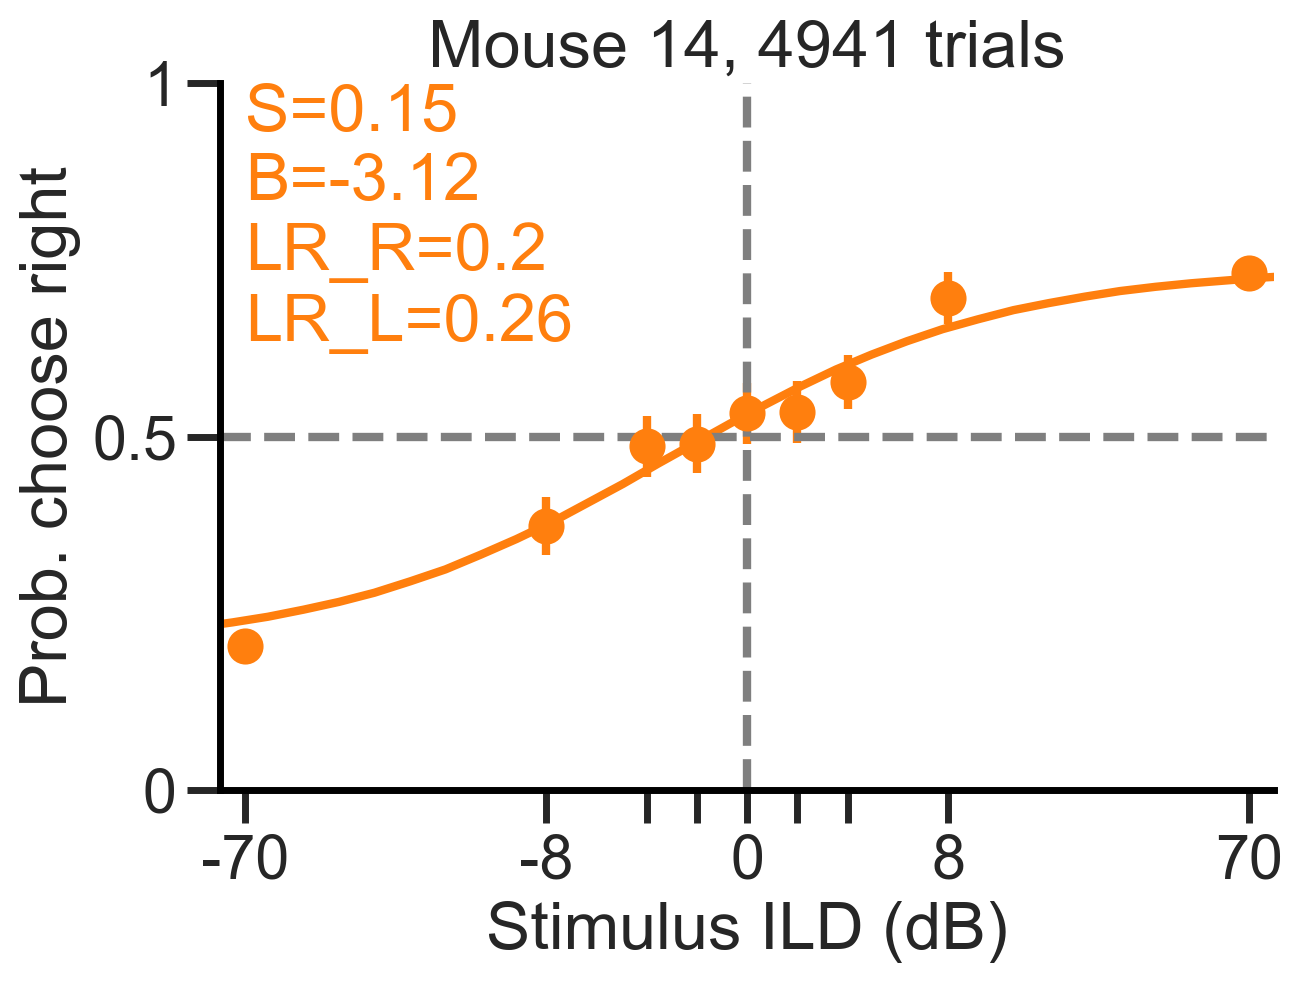

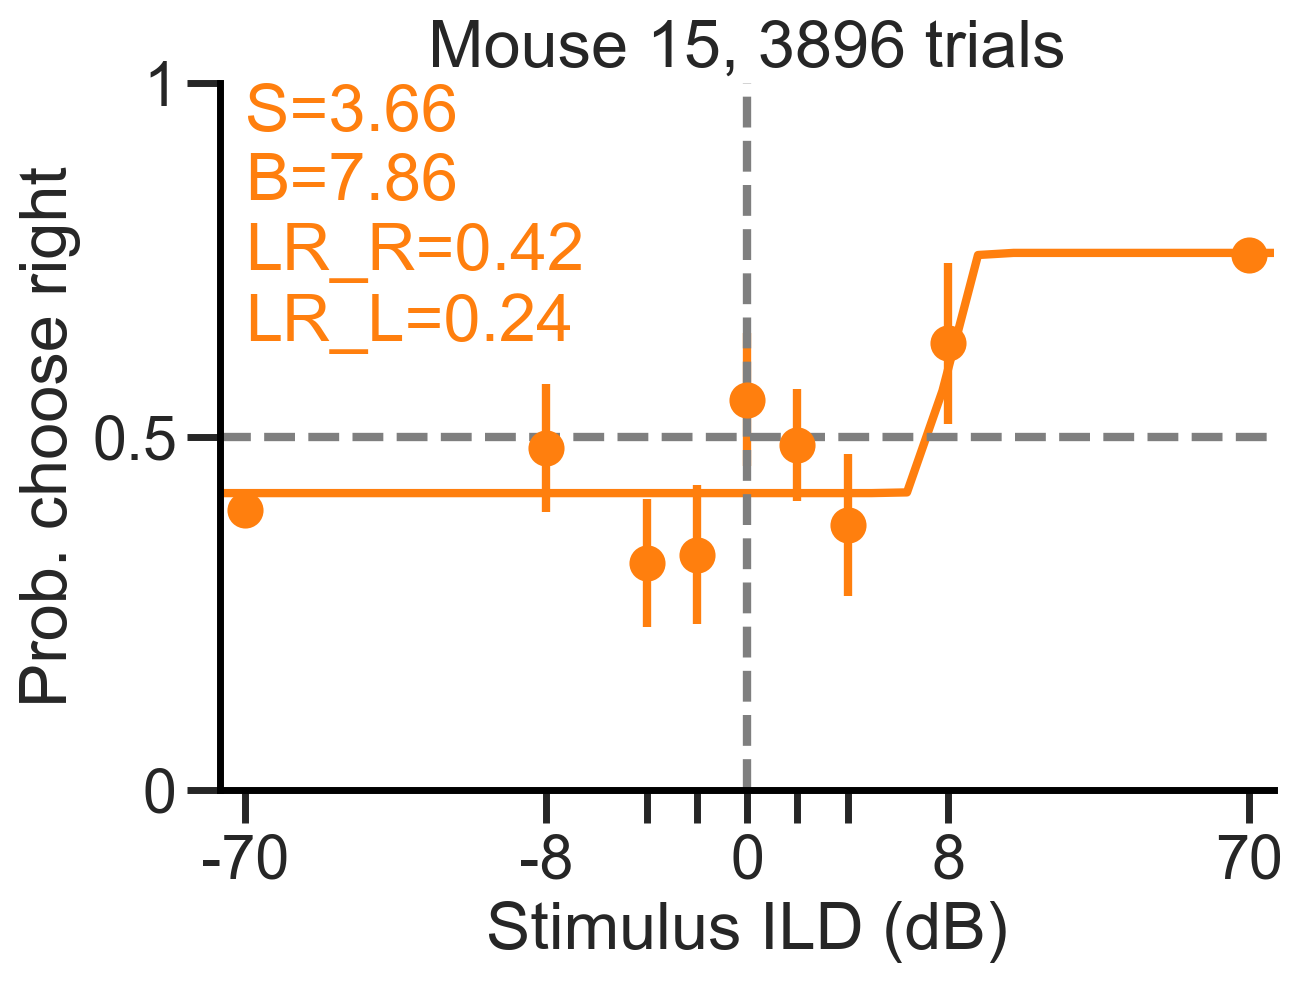

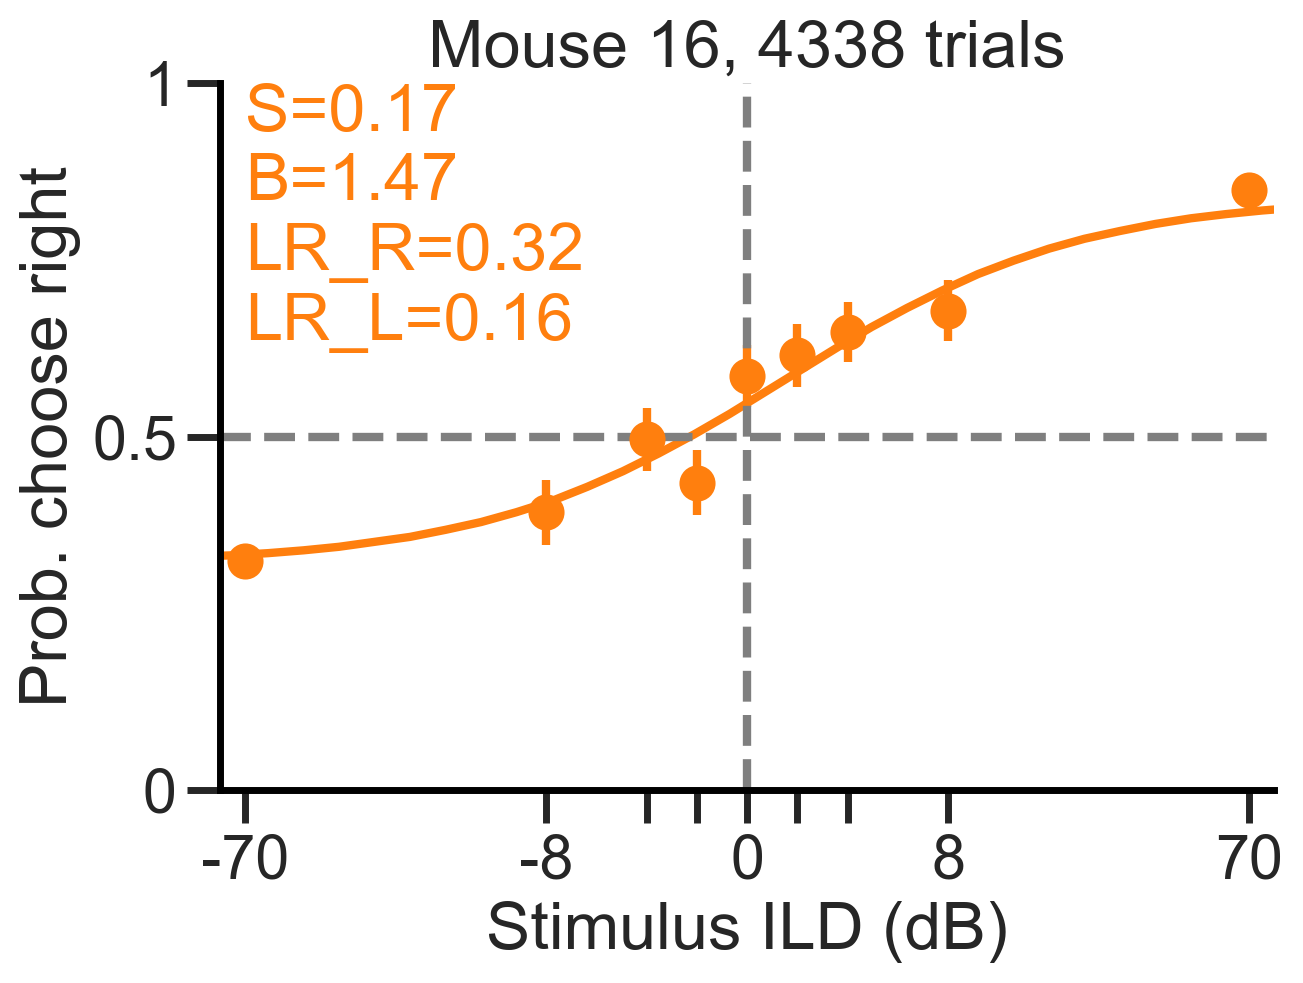

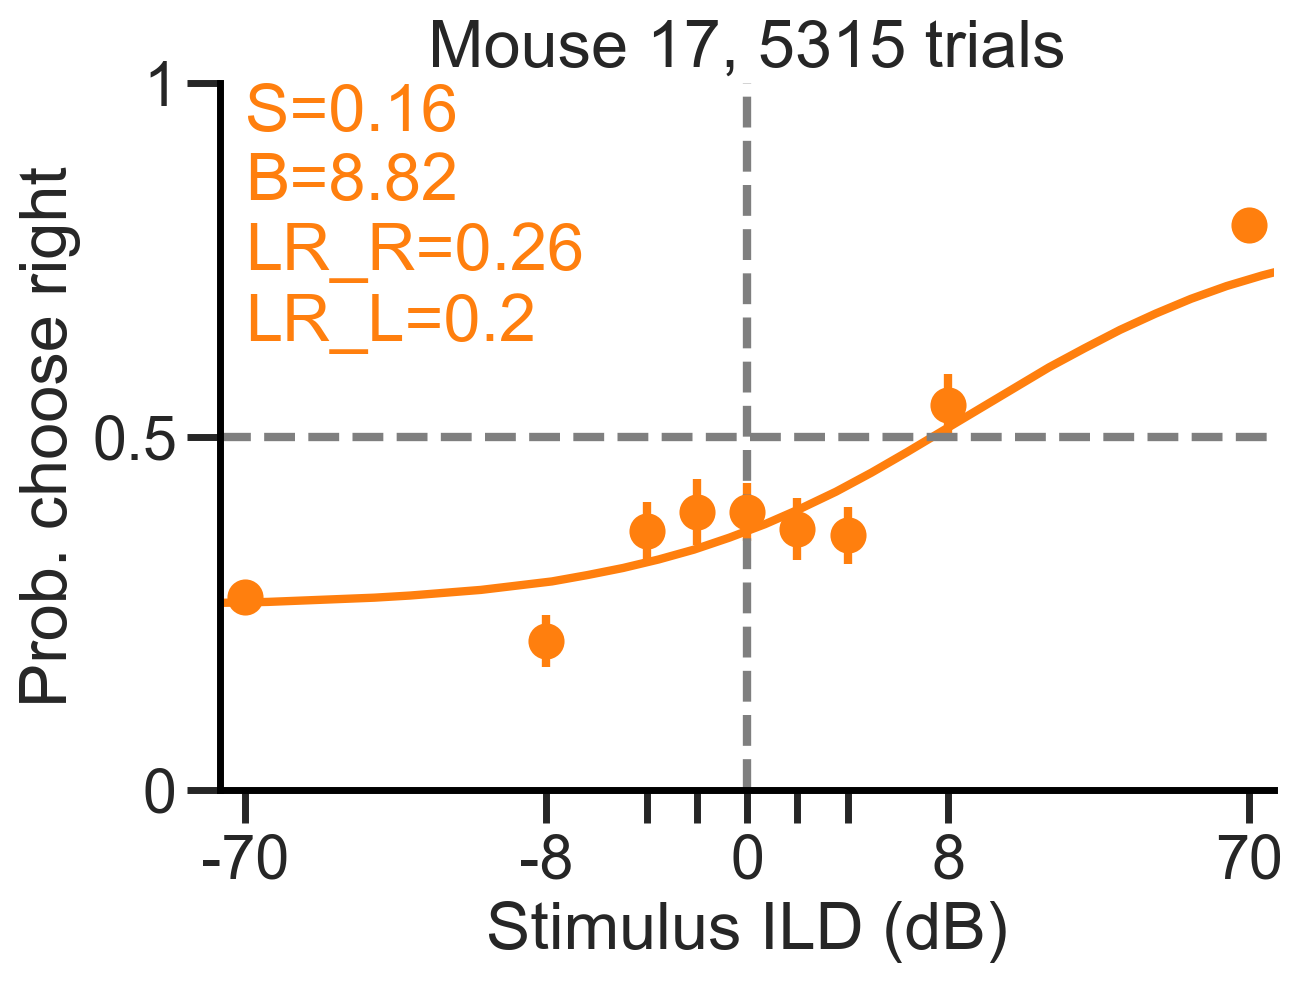

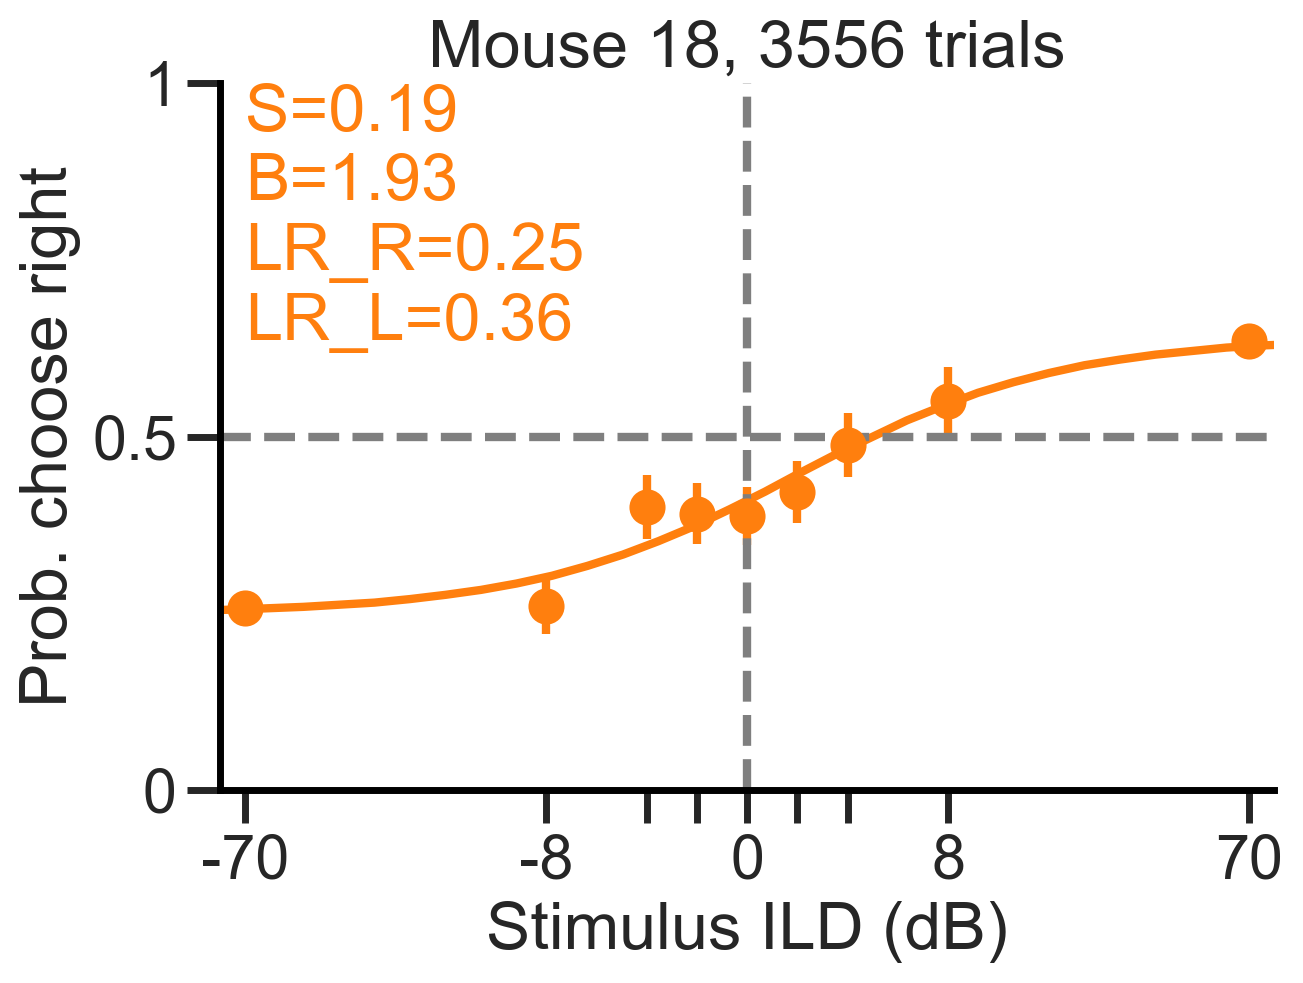

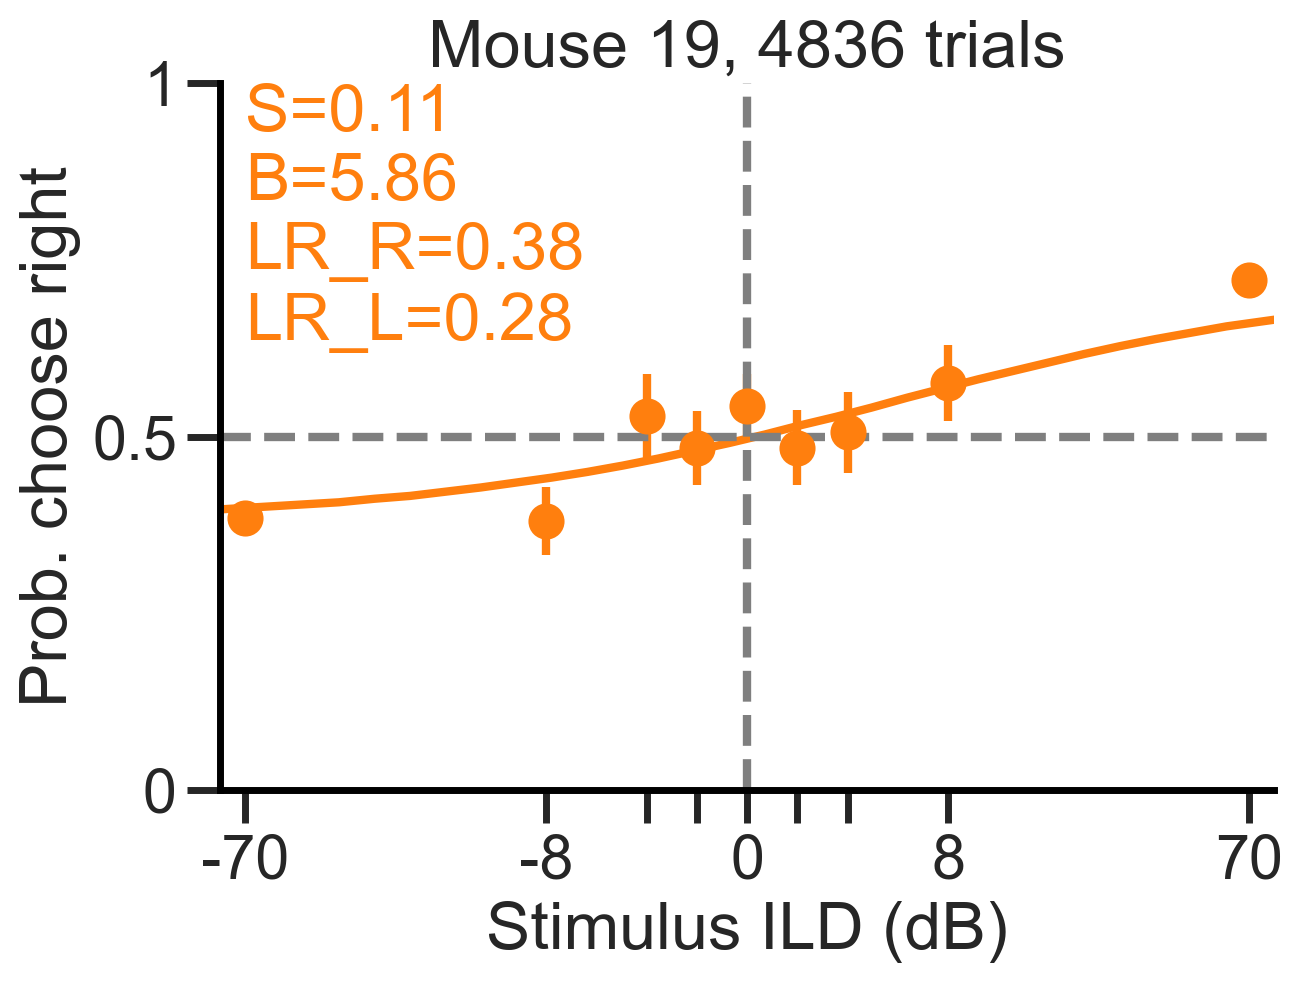

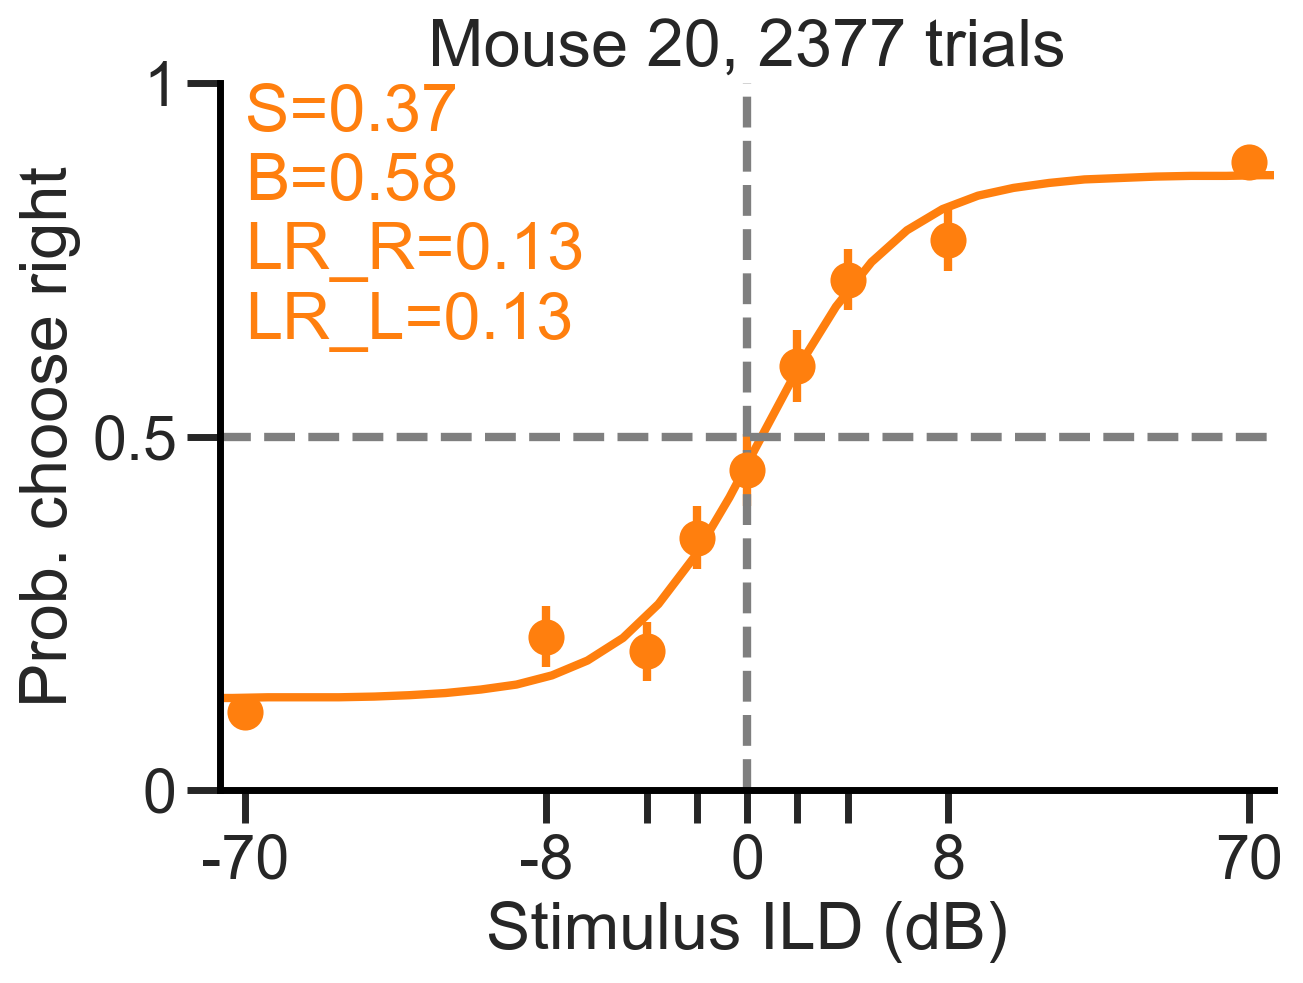

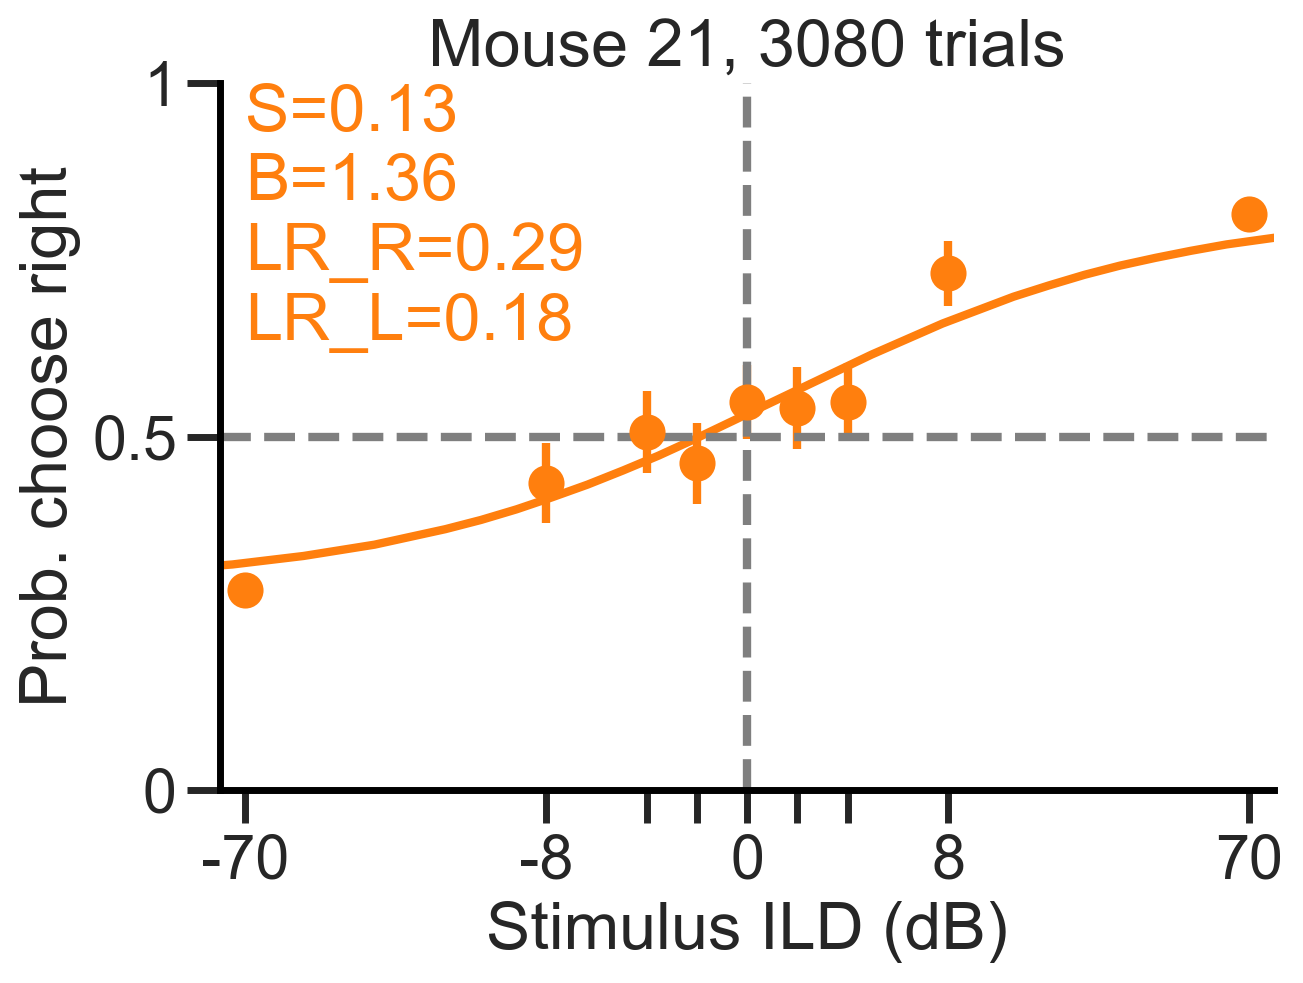

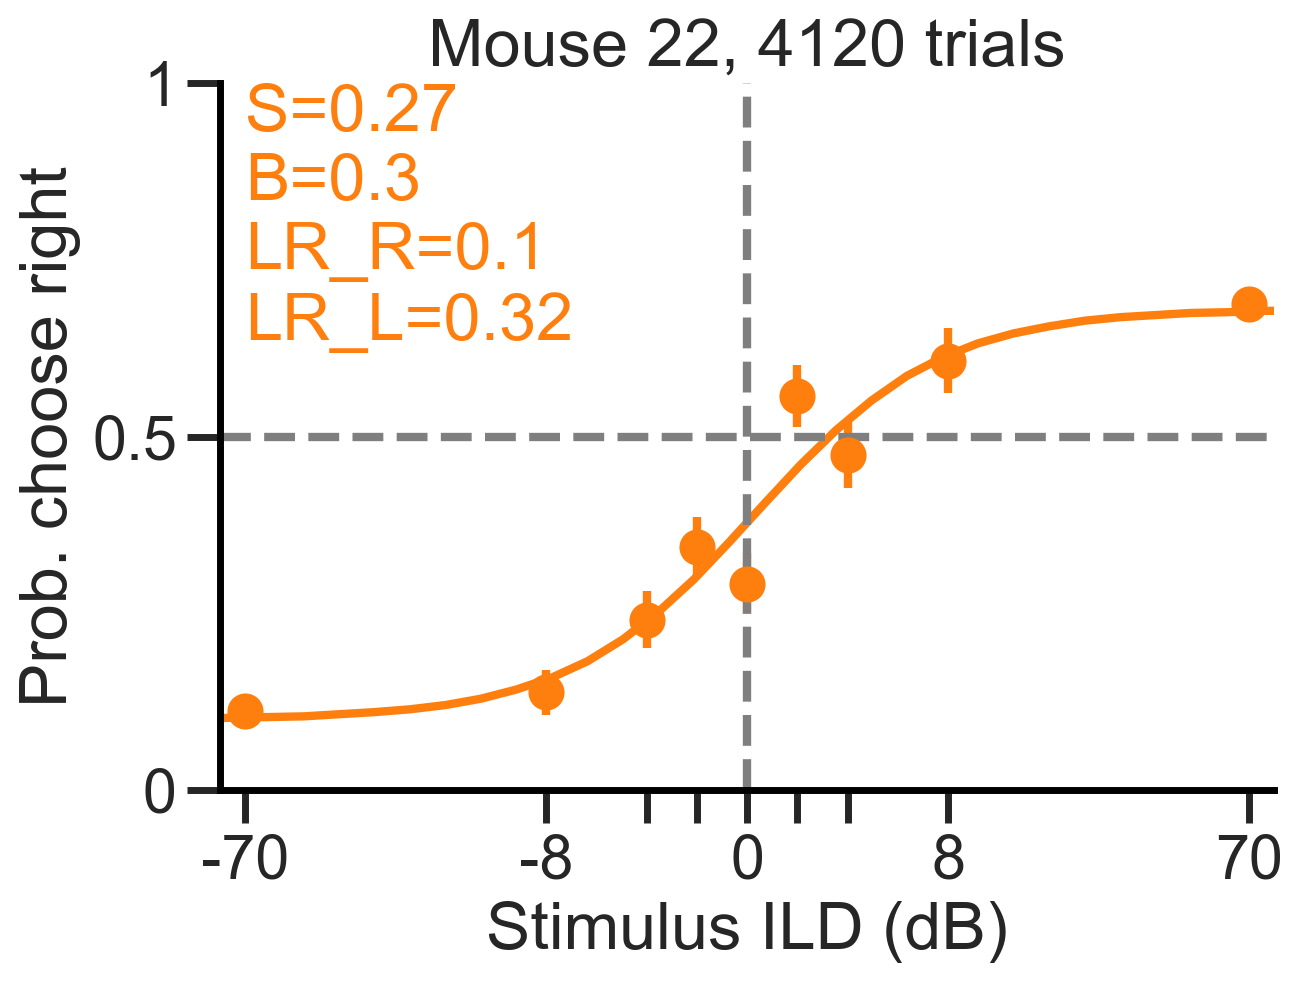

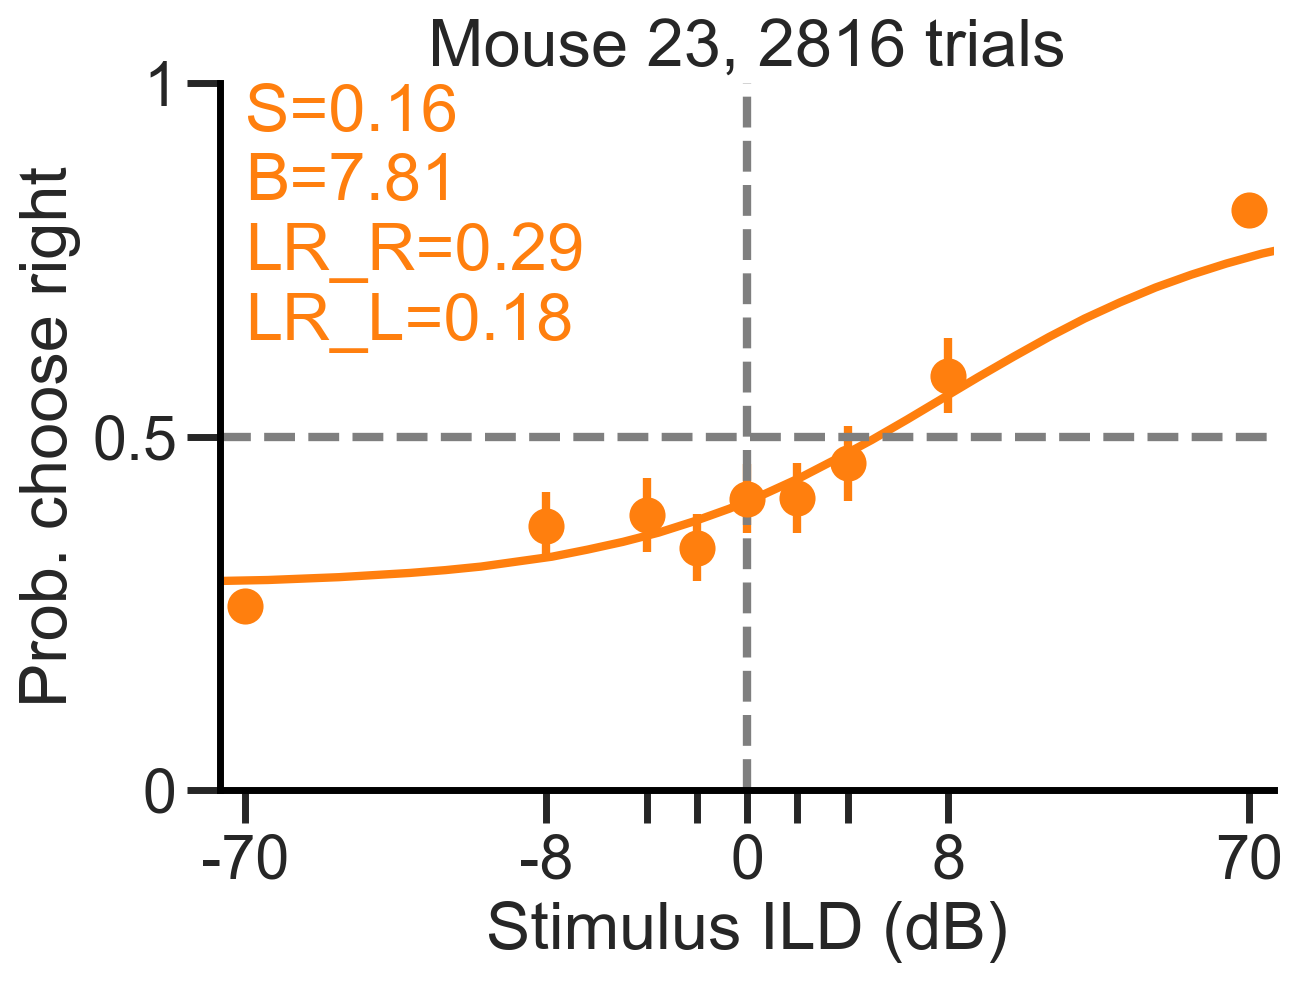

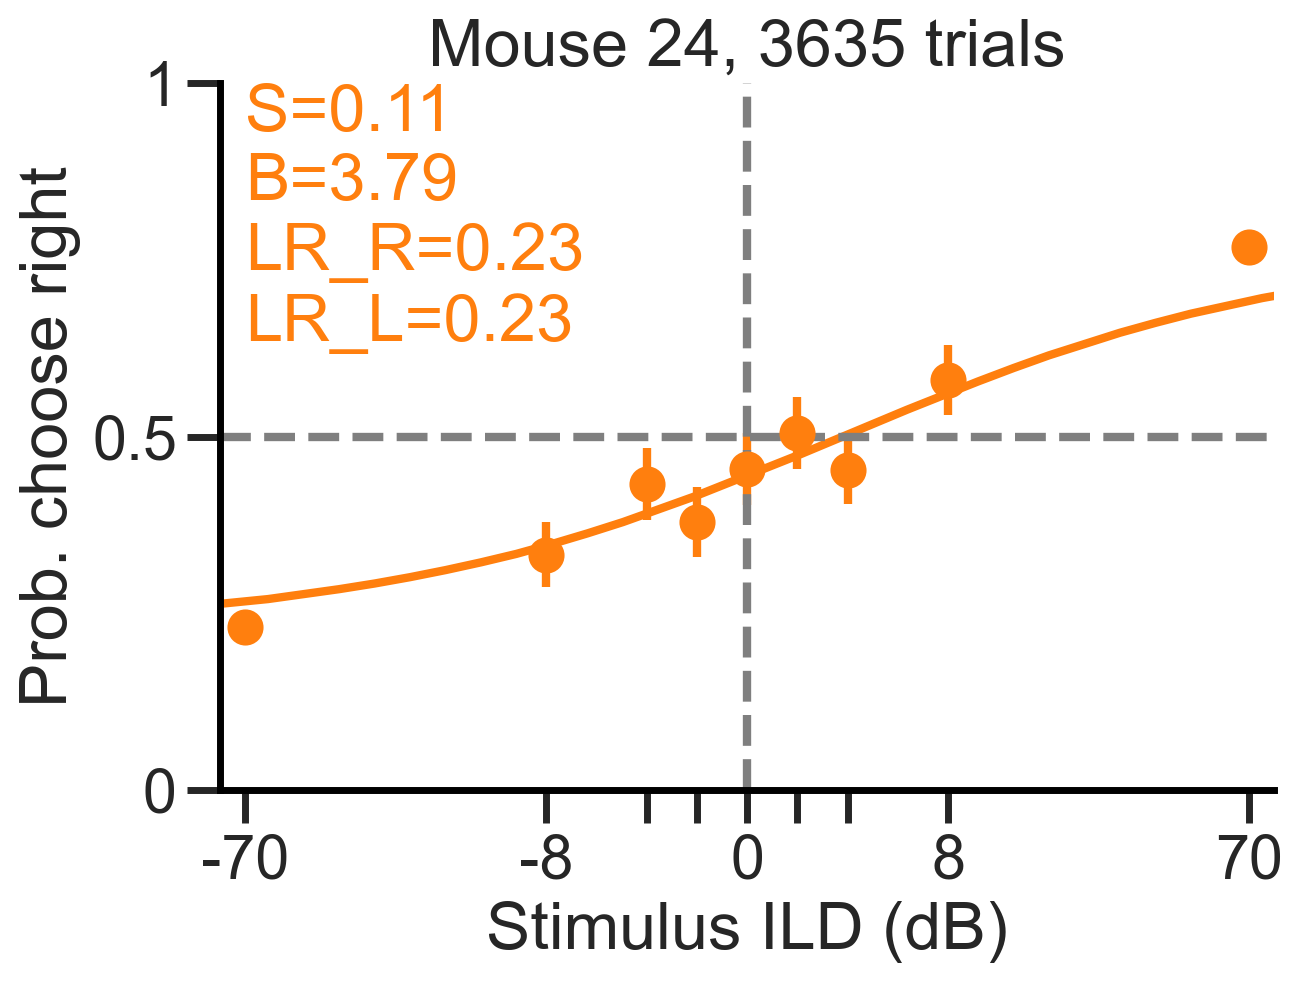

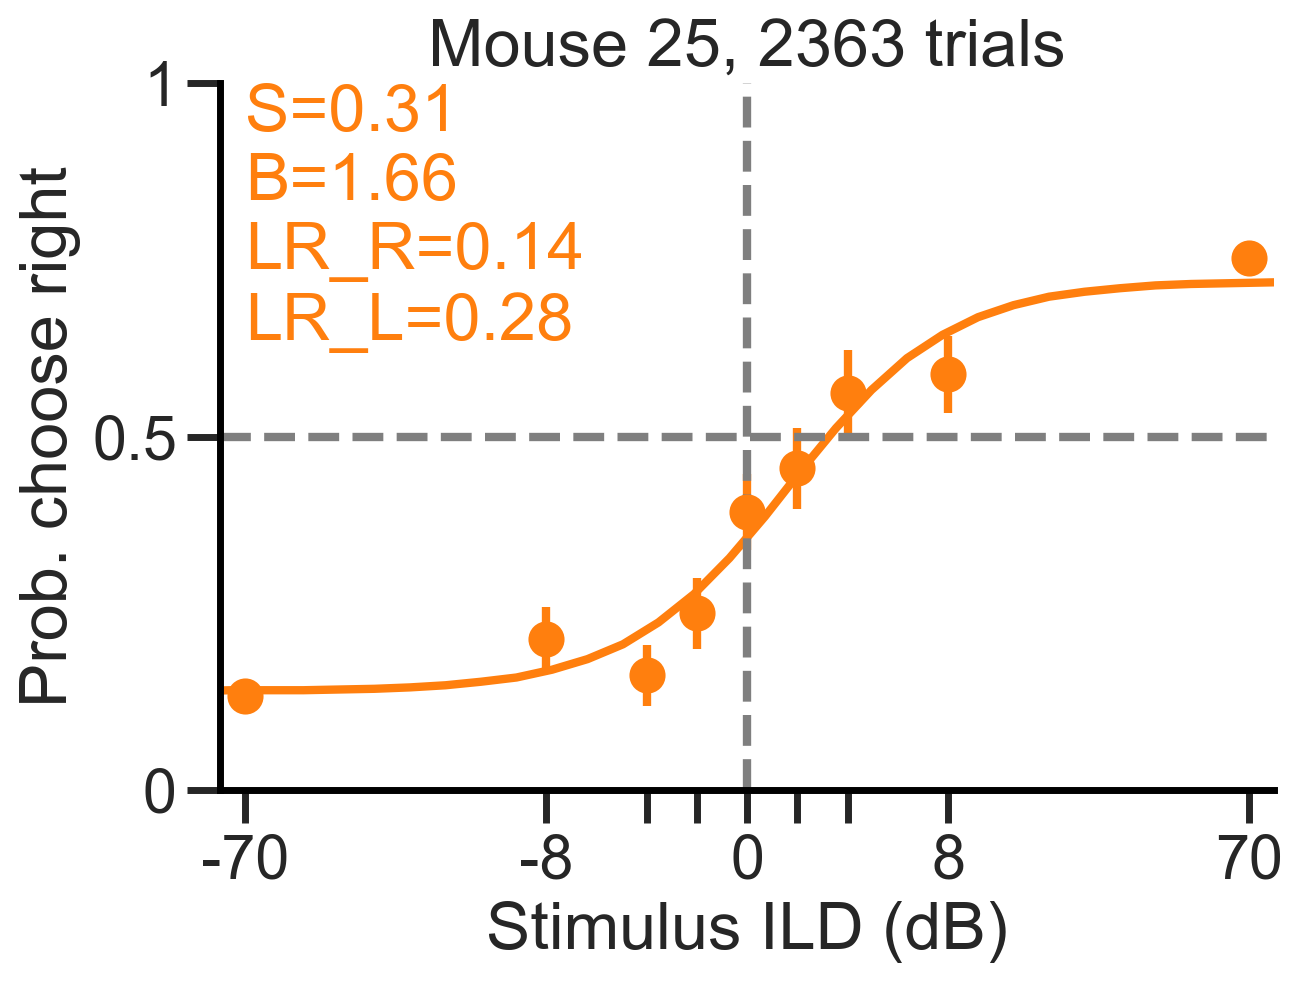

In [15]:
experiment = '2AFC_6'
cherrypick(df_behavior, experiment)

# Save all notebook's figures

In [16]:
# Whole notebook ouputs (no input or prompt, only Markdown and figures)
# As HTML
!jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# As PDF
!jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt

# Export all figures
save_notebook_files('notebook.ipynb')

[NbConvertApp] Converting notebook notebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 38 image(s).
[NbConvertApp] Writing 5203273 bytes to notebook.html
[NbConvertApp] Converting notebook notebook.ipynb to pdf
[NbConvertApp] Support files will be in notebook_files/
[NbConvertApp] Making directory ./notebook_files
[NbConvertApp] Writing 30280 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] CRITICAL | xelatex failed: ['xelatex', 'notebook.tex', '-quiet']
b"This is XeTeX, Version 3.141592653-2.6-0.999997 (TeX Live 2025) (preloaded format=xelatex)\n restricted \\write18 enabled.\nentering extended mode\n(./notebook.tex\nLaTeX2e <2024-11-01> patch level 2\nL3 programming layer <2025-01-18>\n(/usr/local/texlive/2025basic/texmf-dist/tex/latex/base/article.cls\nDocument Class: article 2024/06/29 v1.4n Standard LaTeX document class\n(/usr/local/texlive/2025basic/texmf-dist/